Integrantes do Grupo:
- Anselmo Faria Alvarez Júnior
- Augusto José Mangini dos Santos
- Julio Cesar da Silva

# INF-0616 - Projeto 2: Redes neurais

Professora: Esther Colombini -- esther@ic.unicamp.br

Monitor: Jesus Paucar -- j236865@dac.unicamp.br

Este *notebook* faz parte da disciplina INF-0616 no curso de extensão MDC.  

Instituto de Computação - Unicamp 2026

In [33]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

from IPython.display import display

In [34]:
np.random.seed(12049)

plt.rcParams['figure.figsize'] = (12, 6)

#### Lendo o conjunto de dados

O conjunto de dados consiste em reclamações de clientes a cerca de produtos/serviços oferecidos em uma instituição bancária. ***Garanta que o arquivo*** `customer-issues.csv` ***está no mesmo diretório do notebook***.

In [35]:
from google.colab import drive
drive.mount('/content/drive')
import os
caminho_pasta = '/content/drive/My Drive/Colab Notebooks/mdc-ml-pt2/Trabalho 2/'

# Verifique se o caminho da pasta existe
if os.path.exists(caminho_pasta):
    # Mude o diretório atual para a pasta desejada
    os.chdir(caminho_pasta)
    print("Pasta encontrada. Agora você está na pasta:", caminho_pasta)
else:
    print("A pasta especificada não existe:", caminho_pasta)

d = pd.read_csv('customer-issues.csv')
display(d.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta encontrada. Agora você está na pasta: /content/drive/My Drive/Colab Notebooks/mdc-ml-pt2/Trabalho 2/


,date-received,product,sub-product,issue,sub-issue,consumer-message,state,zip-code,tags,via,resolution,timely-response?,disputed?,complaint-id
0,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,AL,352XX,NaN,Web,Closed with explanation,Yes,No,2141773
1,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,PA,177XX,Older American,Web,Closed with explanation,Yes,No,2163100
2,6/15/2015,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,VA,224XX,NaN,Web,Closed with explanation,Yes,No,1420702
3,2/3/2016,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,This company refuses to provide me verificatio...,TX,752XX,NaN,Web,Closed with explanation,Yes,Yes,1772196
4,2/17/2016,Debt collection,Credit card,Improper contact or sharing of info,Talked to a third party about my debt,This complaint is in regards to Square Two Fin...,NE,693XX,NaN,Web,Closed with explanation,Yes,Yes,1790634


##### Exibindo as quatro primeiras mensagens

In [ ]:
print(*d.loc[:4, 'consumer-message'], sep='\n\n')

I have outdated information on my credit report that I have previously disputed that has yet to be removed this information is more then seven years old and does not meet credit reporting requirements

I purchased a new car on XXXX XXXX. The car dealer called Citizens Bank to get a 10 day payoff on my loan, good till XXXX XXXX. The dealer sent the check the next day. When I balanced my checkbook on XXXX XXXX. I noticed that Citizens bank had taken the automatic payment out of my checking account at XXXX XXXX XXXX Bank. I called Citizens and they stated that they did not close the loan until XXXX XXXX. ( stating that they did not receive the check until XXXX. XXXX. ). I told them that I did not believe that the check took that long to arrive. XXXX told me a check was issued to me for the amount overpaid, they deducted additional interest. Today ( XXXX XXXX, ) I called Citizens Bank again and talked to a supervisor named XXXX, because on XXXX XXXX. I received a letter that the loan had b

##### Extraíndo um conjunto de testes válido

As mensagens contidas neste conjunto possuem uma relação temporal.
É importante realizar a separação dos sub-conjuntos de treino/teste respeitando esta relação, de forma a garantir que o modelo não seja treinado sobre amostras no futuro e experimentado sobre o passado.

In [36]:
columna = 'date-received'

d[columna] = (
    d[columna].astype('string').str.strip().str.strip('"').str.strip("'")
)

In [37]:
d[columna] = pd.to_datetime(d[columna], format = "%m/%d/%Y", errors = 'coerce')

In [38]:
d

,date-received,product,sub-product,issue,sub-issue,consumer-message,state,zip-code,tags,via,resolution,timely-response?,disputed?,complaint-id
0,2016-10-01,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,AL,352XX,NaN,Web,Closed with explanation,Yes,No,2141773
1,2016-10-17,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,PA,177XX,Older American,Web,Closed with explanation,Yes,No,2163100
2,2015-06-15,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,VA,224XX,NaN,Web,Closed with explanation,Yes,No,1420702
3,2016-02-03,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,This company refuses to provide me verificatio...,TX,752XX,NaN,Web,Closed with explanation,Yes,Yes,1772196
4,2016-02-17,Debt collection,Credit card,Improper contact or sharing of info,Talked to a third party about my debt,This complaint is in regards to Square Two Fin...,NE,693XX,NaN,Web,Closed with explanation,Yes,Yes,1790634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199965,2016-11-09,Debt collection,Medical,False statements or representation,Attempted to collect wrong amount,Our son was taken to XXXX XXXX XXXX XXXX XXXX ...,NJ,077XX,NaN,Web,Closed with explanation,Yes,No,2201681
199966,2016-01-22,Bank account or service,Checking account,Deposits and withdrawals,NaN,"On XXXX/XXXX/13, without my authorization, Ban...",FL,347XX,NaN,Web,Closed with monetary relief,Yes,No,1753439
199967,2017-02-07,Debt collection,"Other (i.e. phone, health club, etc.)",Cont'd attempts collect debt not owed,Debt is not mine,I had an account with XXXX in XX/XX/XXXX this ...,NY,115XX,Servicemember,Web,Closed,Yes,No,2331270
199968,2017-01-04,Mortgage,Conventional fixed mortgage,"Application, originator, mortgage broker",NaN,I was contacted on XX/XX/XXXX email by XXXX fr...,FL,336XX,NaN,Web,Closed with explanation,Yes,No,2274241


In [39]:
d.sort_values(by='date-received', inplace=True)

### Modelando a classificação de tópicos baseado nas mensagens de clientes

Observando no gráfico de frequências de produto sobre as conversas que este é um problema extremamente desbalanceado. Há, entretanto, amostras suficientes para a modelagem de um estimador de tópico (de produto) levando em consideração o diálogo do cliente.

In [40]:
def frequencies(dataset, column):
    labels, counts = np.unique(dataset[column], return_counts=True)
    p = np.argsort(counts)[::-1]
    labels, counts = labels[p], counts[p]

    (sns
     .barplot(x=[l[:40] for l in labels], y=counts)
     .set_title(f'Occurrences for The {len(labels)} Classes in {column}'))
    plt.xticks(rotation=90)

    return labels, counts

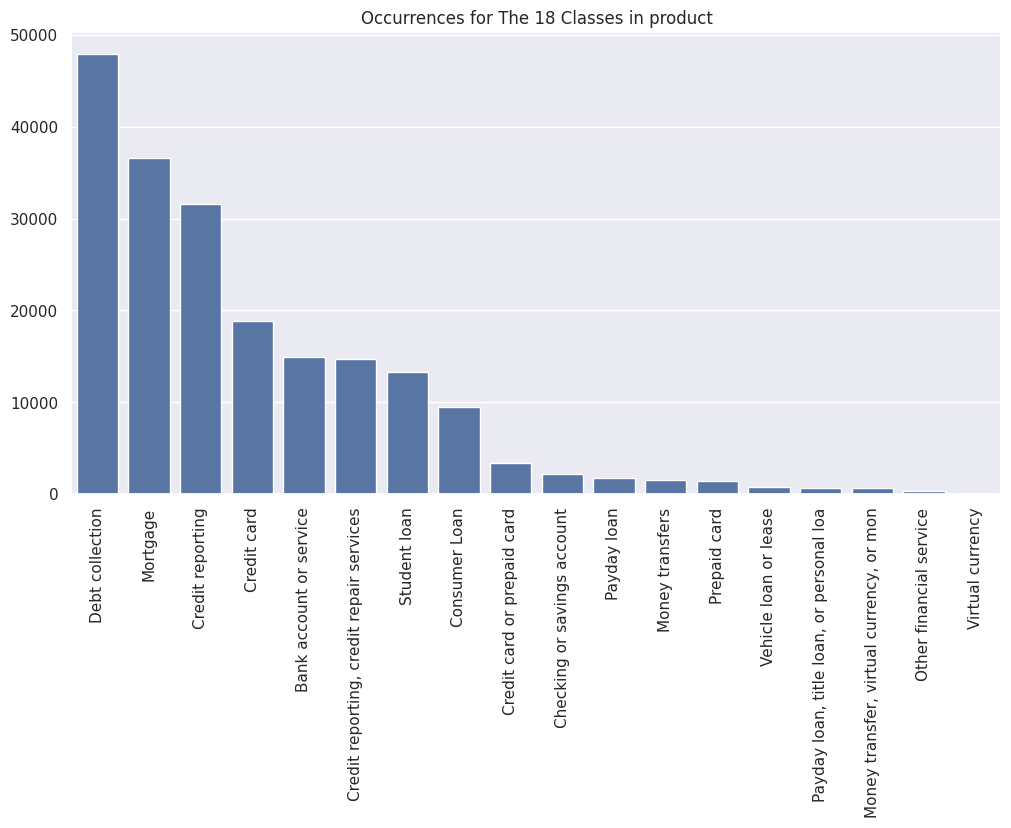

In [41]:
labels, counamts = frequencies(d, 'product')

Simplificamos o problema considerando apenas as classes comuns entre os conjuntos de treinamento e teste:

In [42]:
s = d['product'].isin(labels)
d = d[s]

test_share = .3

d_train, d_test = train_test_split(d, test_size=test_share, shuffle=False)
assert d_train['date-received'].max() <= d_test['date-received'].min()

train_labels = set(d_train['product'].dropna().unique())

test_labels_before = set(d_test['product'].dropna().unique())
unseen_test_labels = test_labels_before - train_labels

print('Classes on train set:')
print(sorted(train_labels))

print('\nTest classes prior to filtering:')
print(sorted(test_labels_before))

print('\nClasses present only in the test set that will be removed:')
print(sorted(unseen_test_labels))

d_test = d_test.loc[
    d_test['product'].isin(train_labels)
].copy()

test_labels_after = set(d_test['product'].dropna().unique())

assert test_labels_after.issubset(train_labels)

print('\nClasses in the test set after filtering:')
print(sorted(test_labels_after))

Classes on train set:
['Bank account or service', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Prepaid card', 'Student loan', 'Virtual currency']

Test classes prior to filtering:
['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit card or prepaid card', 'Credit reporting', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection', 'Money transfer, virtual currency, or money service', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Payday loan, title loan, or personal loan', 'Prepaid card', 'Student loan', 'Vehicle loan or lease', 'Virtual currency']

Classes present only in the test set that will be removed:
['Checking or savings account', 'Credit card or prepaid card', 'Credit reporting, credit repair services, or other personal consumer reports', 'Money transfer, virtual cu

In [43]:
x_train, x_test = d_train['consumer-message'], d_test['consumer-message']
y_train, y_test = d_train['product'], d_test['product']

Verificamos se as etiquetas no conjunto de treino e no conjunto de teste são as mesmas.

In [ ]:
train_labels = set(y_train.unique())
test_labels = set(y_test.unique())

unseen_test_labels = test_labels - train_labels
missing_test_labels = train_labels - test_labels

print('Classes on train:', sorted(train_labels))
print('Classes on test:', sorted(test_labels))

print("\nClasses present only in the test set:")
print(sorted(unseen_test_labels))

Classes on train: ['Bank account or service', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Prepaid card', 'Student loan', 'Virtual currency']
Classes on test: ['Bank account or service', 'Consumer Loan', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Prepaid card', 'Student loan', 'Virtual currency']

Classes present only in the test set:
[]


Vamos codificar as palavras na conversa utilizando o TF-IDF, gerando um vetor de características baseadas nas frequências de ocorrência das palavras no documento e em todo o conjunto de dados.

In [44]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

features = 1024

encoder = make_pipeline(TfidfVectorizer(min_df=5,
                                        stop_words='english',
                                        strip_accents='unicode',
                                        max_features=features),
                        StandardScaler(with_mean=False))

x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)

label_enc = LabelEncoder()
ye_train = label_enc.fit_transform(y_train)
ye_test = label_enc.transform(y_test)

In [45]:
# n_classes era definido na célula 48 (bloco PyTorch, que estamos pulando)
n_classes = len(label_enc.classes_)

from sklearn.metrics import classification_report

import gc
x_train_dense = x_train.toarray().astype('float32')
x_test_dense  = x_test.toarray().astype('float32')
gc.collect()

print(n_classes, x_train_dense.shape, x_train_dense.dtype)


12 (139979, 1024) float32


## Treinando um regressor logístico para classificar produto
**Atividade (1 pt):** treine um regressor logístico, buscando os hiper-parâmetros com *grid-search*.

temos x_train, x_test, ye_train, ye_test

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# modelo básico
log_reg = LogisticRegression(max_iter=1000, random_state=42, solver='saga')

# hiperparâmetros a serem testados
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10]
}

# Grid Search
grid_search = GridSearchCV(
    log_reg,
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

In [ ]:
grid_search.fit(x_train, ye_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, random_state=42,
                                          solver='saga'),
             n_jobs=-1, param_grid={'C': [0.001, 0.01, 0.1, 1, 10]},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search.best_score_)
print(grid_search.best_params_)
print(grid_search.best_estimator_)
g = grid_search.best_estimator_

0.8283528558068957
{'C': 0.01}
LogisticRegression(C=0.01, max_iter=1000, random_state=42, solver='saga')


In [ ]:
y_pred = g.predict(x_test)

Iremos calcular a matriz de confusão relativa $R$, que guarda porcentagens de incidências em vez das contagens absolutas, e plotar o heatmap dessa matriz. Além disso, iremos calcular a distribuição de confiança nas predições por classe (mais próximos de `1.0` --> mais confiante):

In [46]:
def evaluate(y, p, probabilities, labels=None):
    # Cálculo das métricas de acerto.
    print(f'Accuracy: {metrics.accuracy_score(y, p):.3f}')
    print(f'Accuracy (balanced): {metrics.balanced_accuracy_score(y, p):.3f}')

    # Calculo da matriz de confusão.
    c = metrics.confusion_matrix(y, p)
    r = c / c.sum(axis=1, keepdims=True)

    # Impressão dos gráficos.
    (plt
     .figure(figsize=(16, 12))
     .suptitle('Matriz de confusão', fontsize=20))
    sns.heatmap(r,
                cmap="YlGnBu", linewidths=.5, annot=True, fmt=".1%",
                xticklabels=labels, yticklabels=labels, cbar=False)

    (plt
     .figure(figsize=(16, 12))
     .suptitle('Distribuição de confiança para cada classe', fontsize=20))

    for i in np.unique(y):
        # Para cada classe `i`, seleciona suas amostras e filtra a confiança
        # do modelo em predizer estas amostras como sendo da classe `i`.
        sns.kdeplot(x = probabilities[y.ravel() == i][:, i],
                    fill = True,
                    label = labels[i] if labels is not None else f'Classe {i}',
                    alpha = 0.4)

    plt.xlabel("Confiança do modelo")
    plt.ylabel("Densidade")
    plt.legend()

Vamos utilizar a função `evaluate` para avaliar o modelo treinado anteriormente:

Accuracy: 0.840
Accuracy (balanced): 0.589


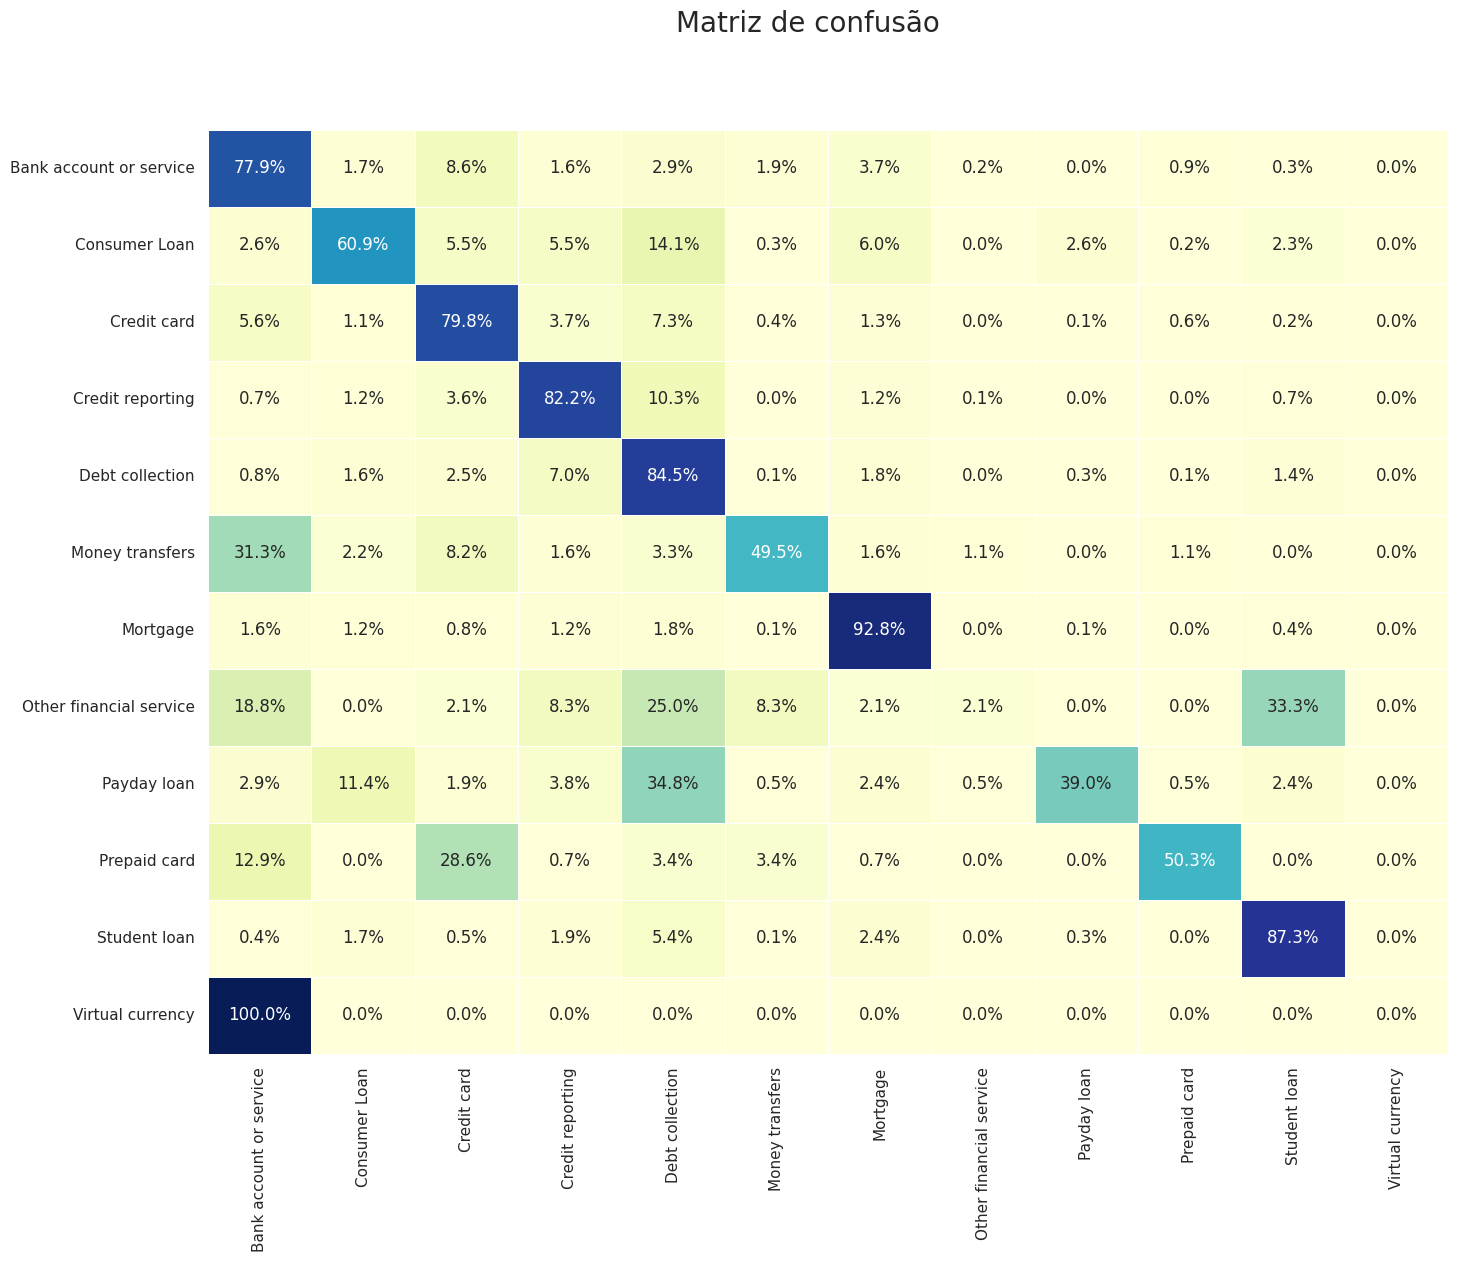

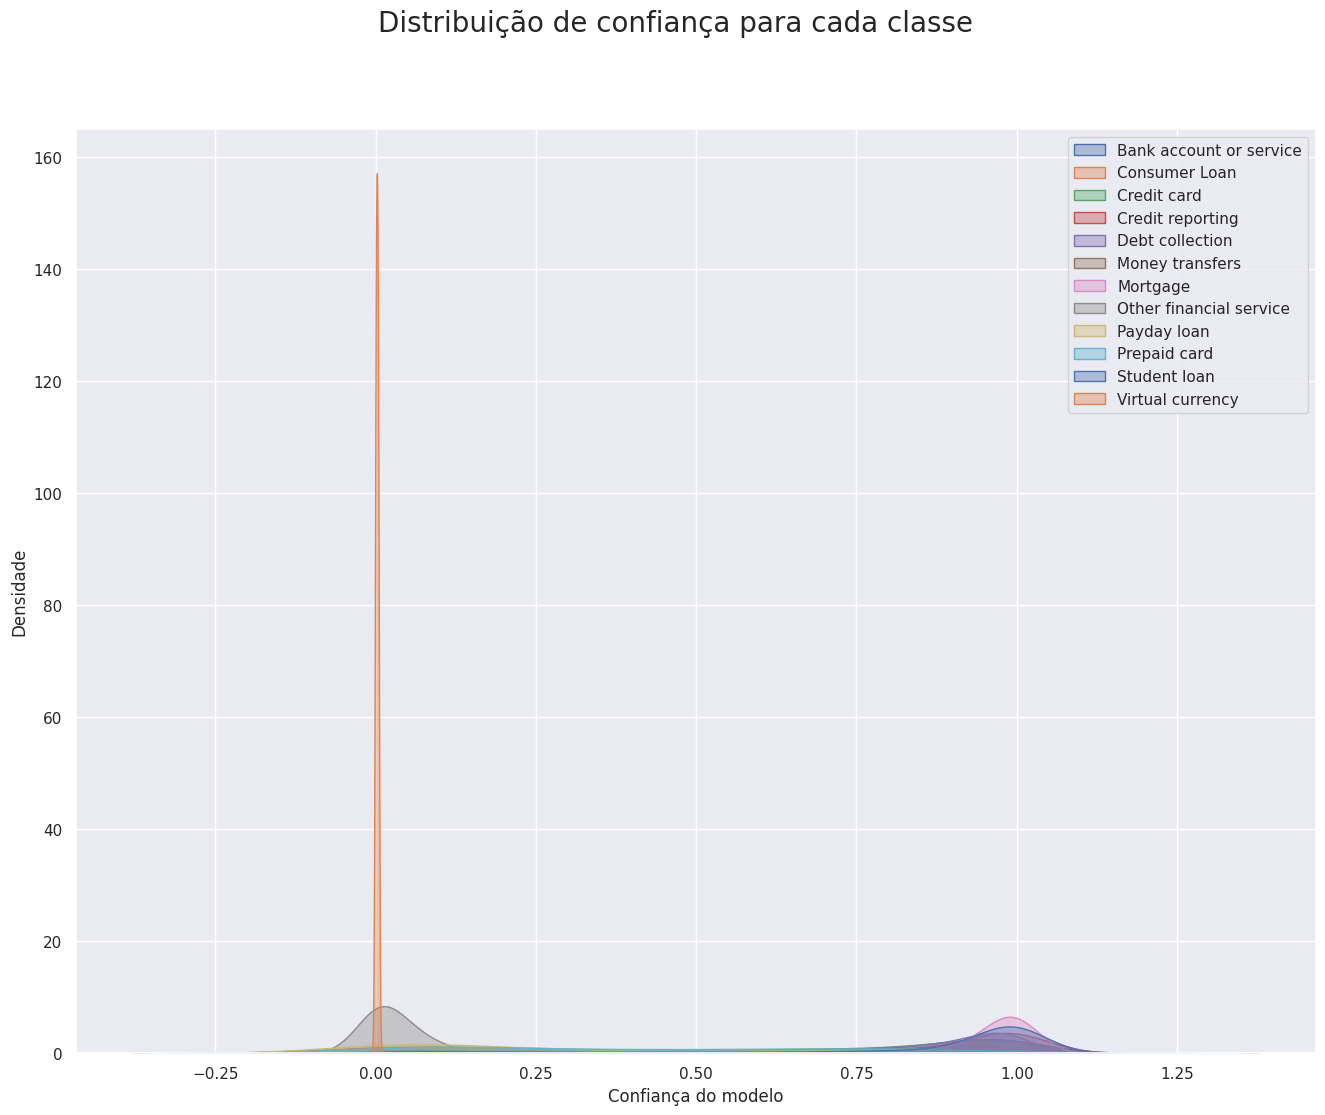

In [ ]:
evaluate(ye_test, g.predict(x_test), g.predict_proba(x_test), labels=label_enc.classes_)

In [47]:
def plot_confidence(y, probabilities, labels=None, min_samples=10):
    """Versão complementar do gráfico de confiança.

    Na função `evaluate` original, classes com pouquíssimas amostras (ex.:
    'Virtual currency', n=2) produzem um KDE de variância ~zero, gerando um
    pico de densidade que satura o eixo Y e torna as demais curvas ilegíveis.
    """
    plt.figure(figsize=(8, 6)).suptitle(
        'Distribuição de confiança (classes com amostragem suficiente)', fontsize=10)

    ignored = []
    for i in np.unique(y):
        mask = y.ravel() == i
        conf = probabilities[mask][:, i]
        name = labels[i] if labels is not None else f'Classe {i}'

        if mask.sum() < min_samples or np.std(conf) == 0:
            ignored.append(f'{name} (n={mask.sum()})')
            continue

        sns.kdeplot(x=conf, fill=True, label=name, alpha=0.4)

    plt.xlim(0, 1)
    plt.xlabel("Confiança do modelo")
    plt.ylabel("Densidade")
    plt.legend()

    if ignored:
        print(f'Classes omitidas (< {min_samples} amostras): ' + ', '.join(ignored))


Classes omitidas (< 10 amostras): Virtual currency (n=2)


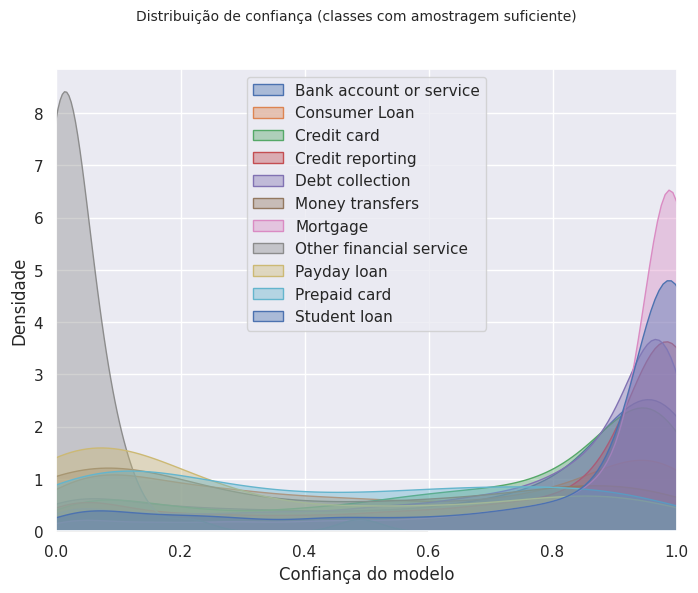

In [ ]:
plot_confidence(ye_test, g.predict_proba(x_test), labels=label_enc.classes_)

**Pergunta (1pt):** considerando o gráfico de distribuição de confiança para o seu modelo treinado, as amostras são classificadas com alta confiança? Há uma grande diferença de confiança entre as diferentes classes?

Considerando o gráfico de de distribuição, sim, é possível afirmar que as amostras são classificadas com alta confiança em geral: A maior parte das classes está concentrada bem perto de 1.0, então quando uma amostra pertence à classe o modelo consegue atribuir probabilidade alta a classe correta. Isso condiz com a matriz de confusão, onde múltiplas classes possuem o resultado de confiança alto na diagonal. Nesse caso, os maiores são Mortgage (92.8%), Student loan (87.3%), Debt collection (84.5%), Credit reporting (82.2%), Credit card (79.8%), Bank account or service (77.9%).

Além disso, também é possível afirmar que há uma grande diferença entre as classes. A visualização original é dominada por um pico de valor aproximado a 157 em 0.0, sendo identificada como a classe de Virtual Currency. Isso occore porque Virtual Currency só possui duas amostras no teste, ambas com probabilidade tendendo a 0 para a própria classe, resultando num artefato com pico de variância nula que cria esse desbalanceamento no gráfico no eixo y.

Refazendo o gráfico sem essa classe, é possível observar melhor o cenário real. A classe de "Other financial service" é quem tem o pico dominante próximo a 0.0, com uma densidade próximo a 8, portanto o modelo não consegue atribuir para essa classe uma probabilidade alta, comportamento parecido para Payday loan. Consumer loan e prepaid card possuem uma incerteza distribuída ao longo do gráfico todo

----------
----------

## Redes Neurais - PyTorch
Iremos treinar alguns modelos de redes neurais, variando número de camadas e quantidade de neurônios em cada camada.

In [ ]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
epochs = 5
batch_size = 128
input_shape = [features]

Prepararemos os dados para que possam ser processados ​​pela nossa rede.

In [ ]:
X_train_tensor = torch.tensor(x_train.toarray(), dtype = torch.float32)
y_train_tensor = torch.tensor(ye_train, dtype = torch.long)

X_test_tensor = torch.tensor(x_test.toarray(), dtype = torch.float32)
y_test_tensor = torch.tensor(ye_test, dtype = torch.long)

Criamos uma classe Dataset personalizada

In [ ]:
from torch.utils.data import Dataset

class FeatureDataste(Dataset):

  def __init__(self, X, y):

    self.X = X
    self.y = y

  def __len__(self):

    return len(self.y)

  def __getitem__(self, idx):

    return self.X[idx], self.y[idx]

**Atividade (1 pt):** Use a classe Dataset criada e defina o objeto DataLoader com uma arquitetura de uma rede neural capaz de classificar os diferentes produtos a partir da conversa dos clientes. Compile a sua rede com a loss `categorical_crossentropy`, optimizador `SGD` e defina as métricas relevantes para o problema.

In [ ]:
from torch.utils.data import DataLoader

batch_size = 128
train_dataset = FeatureDataste(X_train_tensor, y_train_tensor)
test_dataset = FeatureDataste(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle=False)

In [ ]:
x_batch, y_batch = next(iter(train_loader))
print(f'Shape of x_batch: {x_batch.shape}')
print(f'Shape of y_batch: {y_batch.shape}')

Shape of x_batch: torch.Size([128, 1024])
Shape of y_batch: torch.Size([128])


Definindo a rede neural

In [ ]:
import torch.nn as nn
import torch.optim as optim

n_classes = len(label_enc.classes_)

class ProductClassifier(nn.Module):
  def __init__(self, input_dim, n_classes):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, n_classes) # Changed from 128 to 256
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    return self.fc3(x)

In [ ]:
model = ProductClassifier(input_dim=features, n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-2)

Como visto no gráfico de confiança, esse é um dataset desbalanceado, portanto a métrica relevante para avaliação desse problema é a balanced_accuracy_score por época, similar ao que foi feito no exemplo de MNIST de aula, e a acurácia por classe no final da avaliação

### Treinando a rede neural

**Atividade (1 pt):** treine o modelo definido acima sobre o conjunto, respeitando as seguintes regras:

1. Separe um subconjunto do treino para validação.
2. Utilize alguma métrica de referência que você considere importante para o problema para conservar os parâmetros que melhor generalizam o problema (salve o modelo com nome de `weights.pth`).

In [ ]:
from tqdm import tqdm
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [ ]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor,
    test_size=0.2, random_state=42, stratify=y_train_tensor.numpy()
)

train_dataset = FeatureDataste(X_train_split, y_train_split)
val_dataset   = FeatureDataste(X_val_split, y_val_split)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs = 10, device = 'cpu', save_path = 'weights.pth'):

  model.to(device)
  history = {'train_loss': [], 'val_loss': [], 'train_bal_acc': [], 'val_bal_acc': []}
  best_val_bal_acc = 0.0

  for epoch in range(epochs):
    model.train()
    train_loss, train_preds, train_labels = 0.0, [], []

    loop = tqdm(train_loader, desc = f'Epoch [{epoch + 1} / {epochs}]', leave = False)
    for x, label in loop:
      x, label = x.to(device), label.to(device)

      optimizer.zero_grad()
      outputs = model(x)
      loss = criterion(outputs, label)
      loss.backward()
      optimizer.step()

      train_loss += loss.item() * x.size(0)
      _, preds = torch.max(outputs, 1)
      train_preds.extend(preds.detach().cpu().numpy())
      train_labels.extend(label.detach().cpu().numpy())
      loop.set_postfix(loss = loss.item())

    train_loss /= len(train_loader.dataset)
    train_bal_acc = balanced_accuracy_score(train_labels, train_preds)

    model.eval()
    val_loss, val_preds, val_labels = 0.0, [], []
    with torch.no_grad():
      for x, label in val_loader:
        x, label = x.to(device), label.to(device)
        outputs = model(x)
        loss = criterion(outputs, label)

        val_loss += loss.item() * x.size(0)
        _, preds = torch.max(outputs, 1)
        val_preds.extend(preds.detach().cpu().numpy())
        val_labels.extend(label.detach().cpu().numpy())

      val_loss /= len(val_loader.dataset)
      val_bal_acc = balanced_accuracy_score(val_labels, val_preds)

      history['train_loss'].append(train_loss)
      history['val_loss'].append(val_loss)
      history['train_bal_acc'].append(train_bal_acc)
      history['val_bal_acc'].append(val_bal_acc)

      print(f'Epoch [{epoch + 1} / {epochs}] '
            f'Train Loss: {train_loss:.4f}, Train Bal. Acc: {train_bal_acc:.4f} '
            f'| Val Loss: {val_loss:.4f}, Val Bal. Acc: {val_bal_acc:.4f}')

      # Conserva os parâmetros que melhor generalizam
      if val_bal_acc > best_val_bal_acc:
        best_val_bal_acc = val_bal_acc
        torch.save(model.state_dict(), save_path)
        print('-' * 100)
        print(f'Melhor modelo atualizado (Bal. Acc: {best_val_bal_acc:.4f}) salvo em {save_path}')
        print('-' * 100)

  return history

In [ ]:
epochs = 30
history = train_model(model = model,
                      train_loader = train_loader,
                      val_loader = val_loader,
                      criterion = criterion,
                      optimizer = optimizer,
                      epochs = epochs,
                      device = device,
                      save_path = 'weights.pth')

Epoch [1 / 30] Train Loss: 1.4403, Train Bal. Acc: 0.2612 | Val Loss: 0.8683, Val Bal. Acc: 0.3982
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.3982) salvo em weights.pth
----------------------------------------------------------------------------------------------------


Epoch [2 / 30] Train Loss: 0.7261, Train Bal. Acc: 0.4396 | Val Loss: 0.6649, Val Bal. Acc: 0.4556
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.4556) salvo em weights.pth
----------------------------------------------------------------------------------------------------


Epoch [3 / 30] Train Loss: 0.6082, Train Bal. Acc: 0.4692 | Val Loss: 0.6122, Val Bal. Acc: 0.4739
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.4739) salvo em weights.pth
----------------------------------------------------------------------------------------------------


Epoch [4 / 30] Train Loss: 0.5557, Train Bal. Acc: 0.4917 | Val Loss: 0.5821, Val Bal. Acc: 0.5032
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.5032) salvo em weights.pth
----------------------------------------------------------------------------------------------------


Epoch [5 / 30] Train Loss: 0.5195, Train Bal. Acc: 0.5309 | Val Loss: 0.5641, Val Bal. Acc: 0.5306
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.5306) salvo em weights.pth
----------------------------------------------------------------------------------------------------


...

Epoch [26 / 30] Train Loss: 0.1195, Train Bal. Acc: 0.7718 | Val Loss: 0.6252, Val Bal. Acc: 0.6000


Epoch [27 / 30] Train Loss: 0.1069, Train Bal. Acc: 0.7814 | Val Loss: 0.6409, Val Bal. Acc: 0.6039


Epoch [28 / 30] Train Loss: 0.0960, Train Bal. Acc: 0.7917 | Val Loss: 0.6507, Val Bal. Acc: 0.6049


Epoch [29 / 30] Train Loss: 0.0859, Train Bal. Acc: 0.7983 | Val Loss: 0.6679, Val Bal. Acc: 0.6067


Epoch [30 / 30] Train Loss: 0.0772, Train Bal. Acc: 0.8092 | Val Loss: 0.6777, Val Bal. Acc: 0.6135
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.6135) salvo em weights.pth
----------------------------------------------------------------------------------------------------


In [ ]:
best_model = ProductClassifier(input_dim=features, n_classes=n_classes)

In [ ]:
best_model.load_state_dict(torch.load('weights.pth'))
best_model.to(device)
best_model.eval()

ProductClassifier(
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=12, bias=True)
  (relu): ReLU()
)

**Atividade (1 pt):** plote um gráfico de linhas exibindo a evolução dos valores da função *loss* sobre o conjunto de treino e validação. A partir de qual `epoch` a rede começou a super-especializar?

In [ ]:
history_f = pd.DataFrame(history)
history_f.head()

,train_loss,val_loss,train_bal_acc,val_bal_acc
0,1.440288,0.868295,0.261186,0.398242
1,0.726088,0.664868,0.439561,0.455611
2,0.608154,0.612203,0.469171,0.473921
3,0.555733,0.582138,0.491746,0.503208
4,0.519522,0.564139,0.530938,0.530590


In [ ]:
def plot_history(history):
  epochs_range = range(1, len(history['train_loss']) + 1)
  best_epoch = int(np.argmin(history['val_loss'])) + 1

  plt.figure(figsize=(16, 8))

  # --- Loss ---
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, history['train_loss'], label='Train Loss')
  plt.plot(epochs_range, history['val_loss'], label='Val Loss')
  plt.axvline(best_epoch, color='red', linestyle='--',
              label=f'Menor Val Loss (epoch {best_epoch})')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Loss x Epoch')
  plt.legend()

  # --- Balanced Accuracy ---
  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, history['train_bal_acc'], label='Train Balanced Accuracy')
  plt.plot(epochs_range, history['val_bal_acc'], label='Val Balanced Accuracy')
  plt.axvline(best_epoch, color='red', linestyle='--',
              label=f'Menor Val Loss (epoch {best_epoch})')
  plt.xlabel('Epochs')
  plt.ylabel('Balanced Accuracy')
  plt.title('Bal. Accuracy x Epoch')
  plt.legend()

  plt.tight_layout()
  plt.show()

  print(f'Menor Val Loss: {min(history["val_loss"]):.4f} na epoch {best_epoch}')


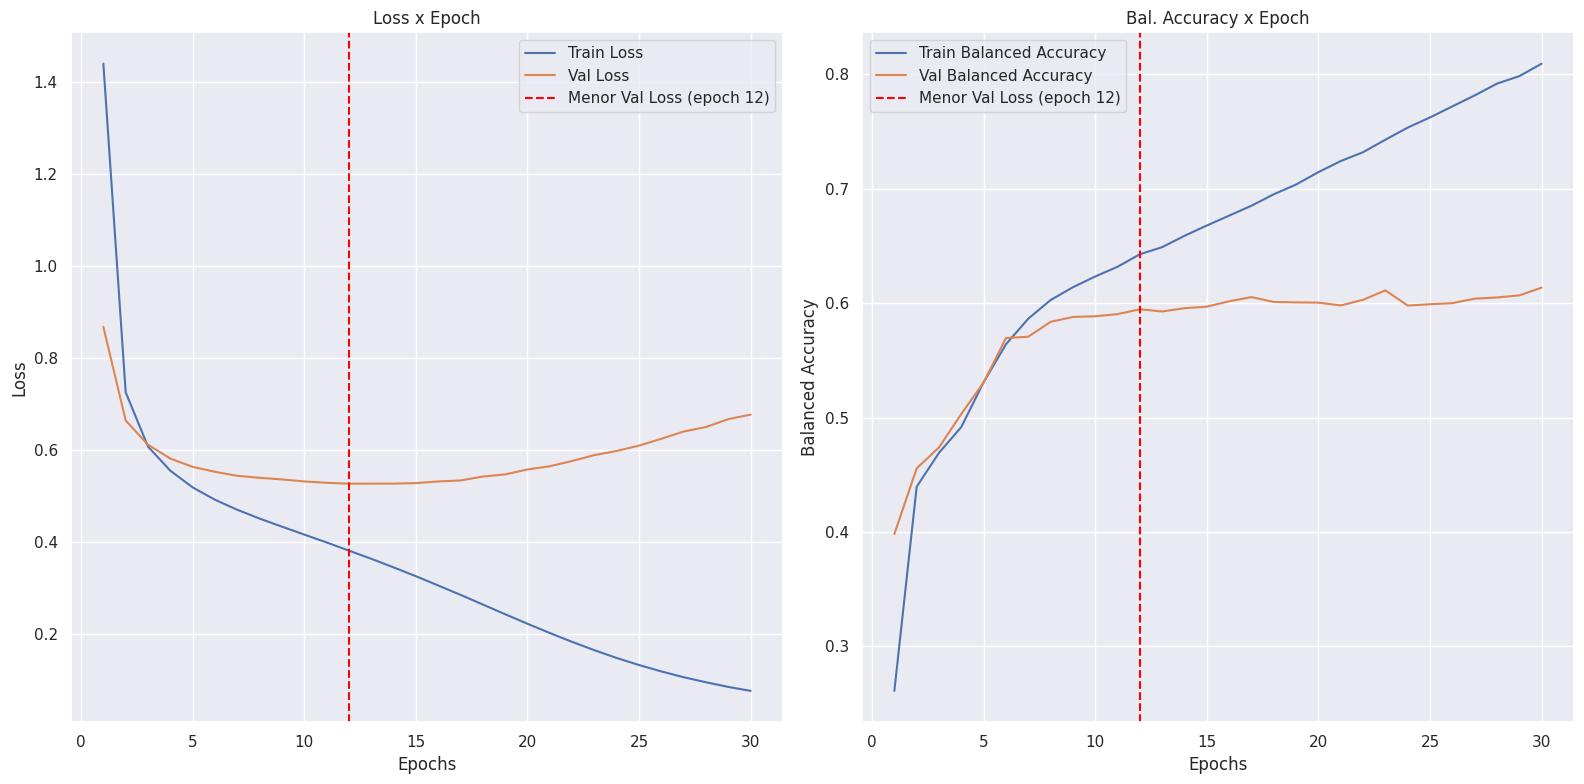

Menor Val Loss: 0.5276 na epoch 12


In [ ]:
plot_history(history = history)

A rede começou a se super-especializar aproximadamente a partir do epoch 14, pois é o ponto onde a loss do dataset de validação é menor entre todas as epochs. A partir disso o loss de validação volta a subir e o loss de treino continua caindo, indicando comportamento de overfitting.

### Avaliando o modelo treinado

**Atividade (1 pt):** teste o modelo treinado utilizando o subconjunto de teste. Reporte a acurácia para cada classe e a matriz de confusão percentual (pode utilizar a função `evaluate` definida anteriormente).

Accuracy: 0.822
Accuracy (balanced): 0.582


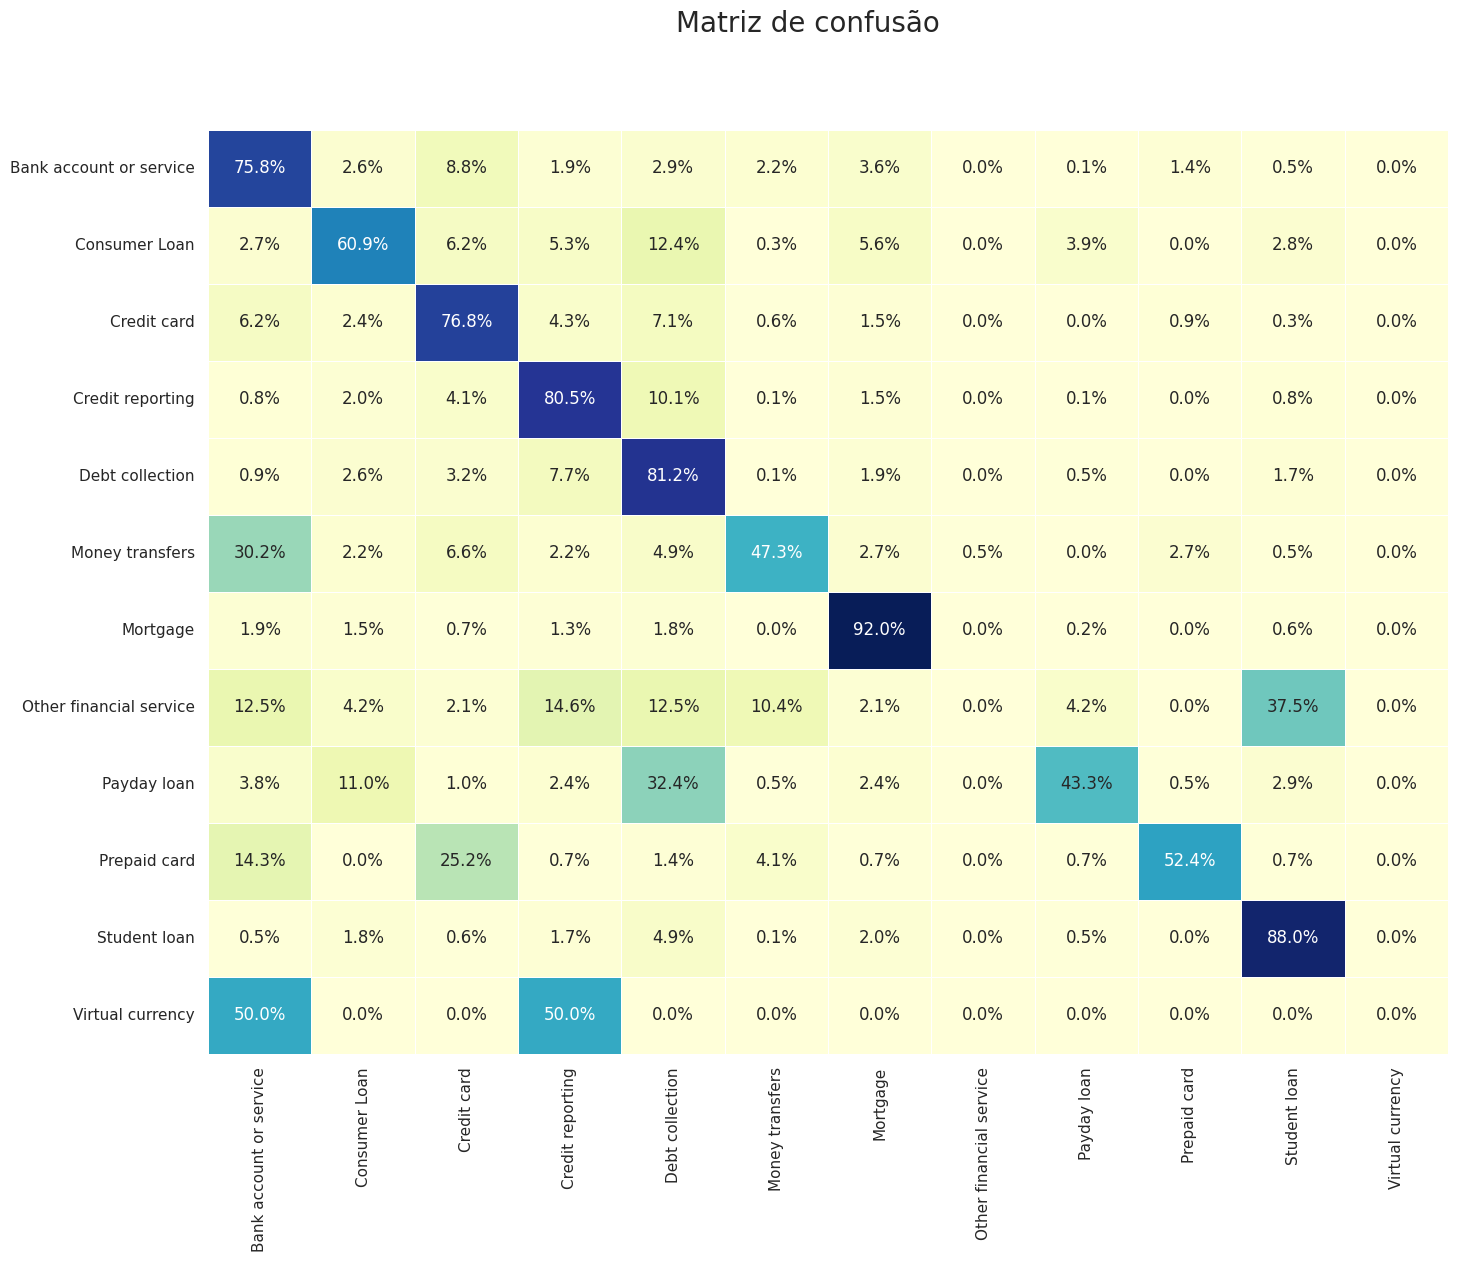

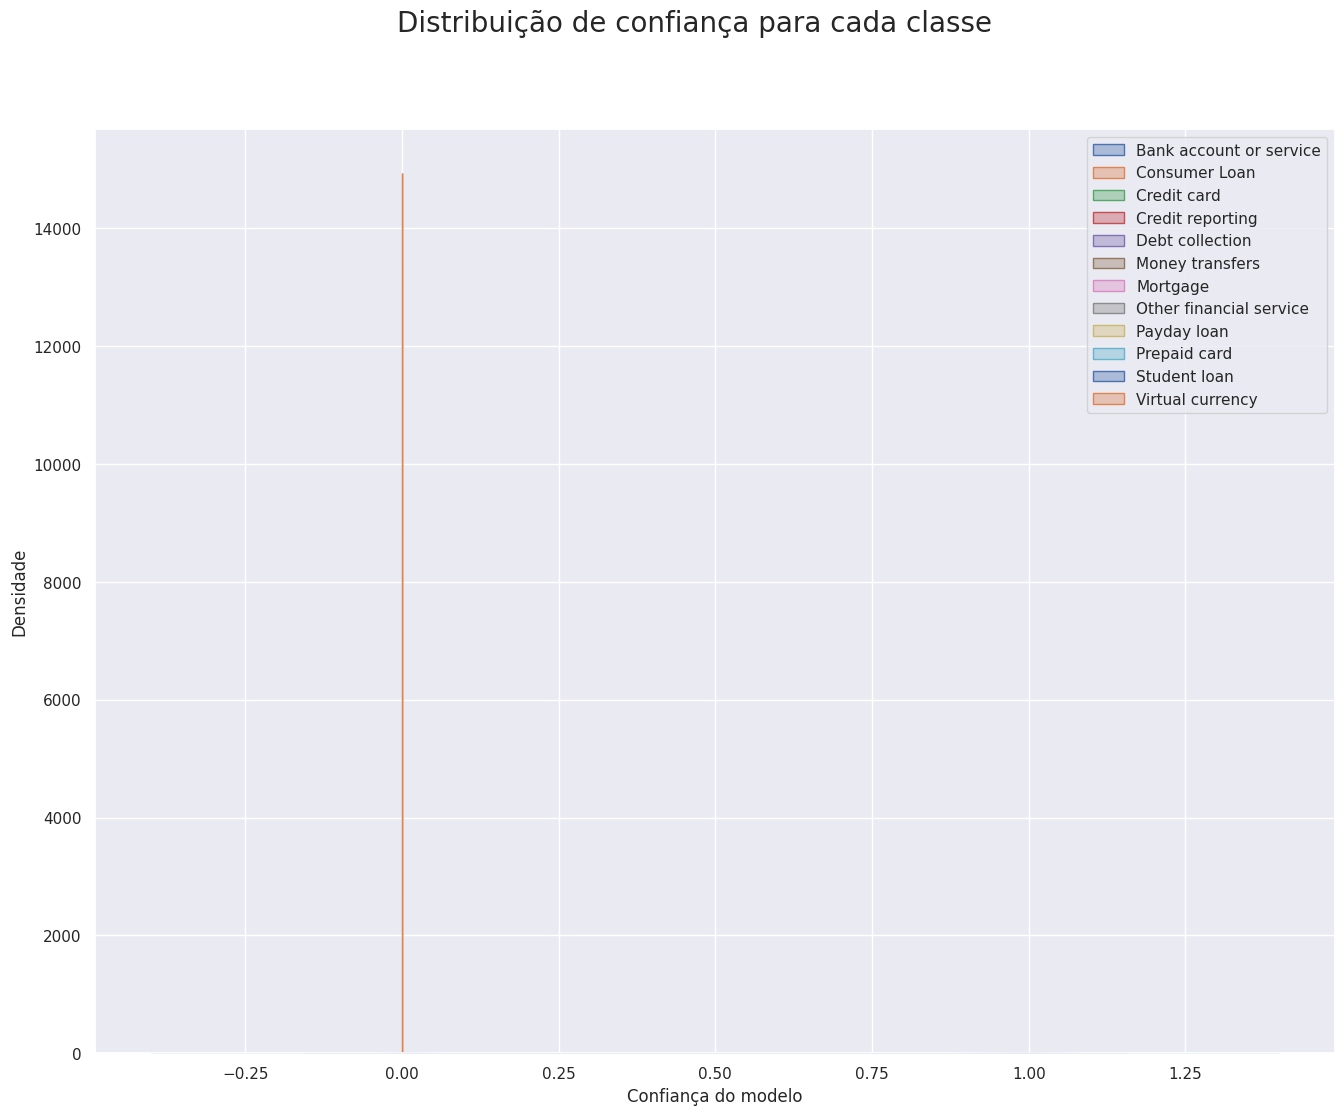

In [ ]:
def predict_all(model, loader, device='cpu'):
  model.eval()
  all_probs, all_labels = [], []

  with torch.no_grad():
    for x, label in loader:
      x = x.to(device)
      outputs = model(x)
      probs = torch.softmax(outputs, dim=1)
      all_probs.append(probs.cpu().numpy())
      all_labels.append(label.numpy())

  return np.concatenate(all_labels), np.concatenate(all_probs)


y_true, probs_test = predict_all(best_model, test_loader, device=device)
y_pred = probs_test.argmax(axis=1)

# Matriz de confusão percentual + distribuição de confiança
evaluate(y_true, y_pred, probs_test, labels=label_enc.classes_)

Classes omitidas (< 10 amostras): Virtual currency (n=2)


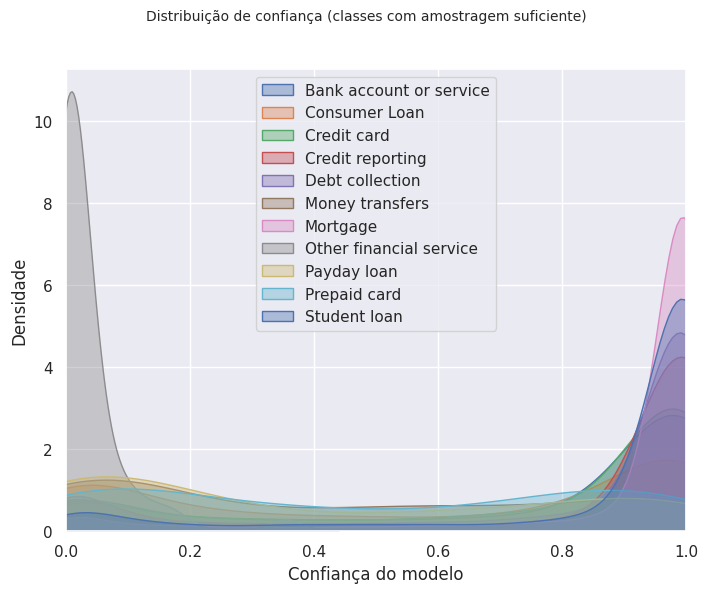

In [ ]:
plot_confidence(y_true, probs_test, labels=label_enc.classes_)

In [ ]:
print(classification_report(y_true, y_pred, target_names=label_enc.classes_))

                         precision    recall  f1-score   support

Bank account or service       0.72      0.76      0.74      2012
          Consumer Loan       0.53      0.61      0.56      1457
            Credit card       0.65      0.77      0.70      2462
       Credit reporting       0.74      0.80      0.77      5063
        Debt collection       0.88      0.81      0.85     13309
        Money transfers       0.46      0.47      0.47       182
               Mortgage       0.91      0.92      0.92      7471
Other financial service       0.00      0.00      0.00        48
            Payday loan       0.35      0.43      0.38       210
           Prepaid card       0.53      0.52      0.53       147
           Student loan       0.92      0.88      0.90      5258
       Virtual currency       0.00      0.00      0.00         2

               accuracy                           0.82     37621
              macro avg       0.56      0.58      0.57     37621
           weighted avg

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


O modelo atinge 83,2% de acurácia e apenas 58,1% de acurácia balanceada. Essa diferença ocorre porque as principais classes do conjunto (Debt collection, Mortgage, Student loan e Credit reporting) representam a maioria do conjunto e ao acertar a probabilidade dessas, a acurácia pura fica inflada. A acurácia balanceada mostra o desempenho real.

Por classe, há uma diferença entre a probabilidade das principais e do resto, assim como a distribuição delas: Mortgage (92%), Student loan (89%), Debt collection (82%), Credit reporting (82%) e Credit card (79%) vão relativamente bem, enquanto Payday loan (38%), Prepaid card (48%) e Money transfers (49%) ficam abaixo. Other financial service e Virtual currency têm recall zero, sendo que têm apenas 48 e 2 amostras de teste, respectivamente, contribuindo para puxar essa acurácia balanceada para baixo.

O gráfico de confiança mostra forte polarização nos extremos (0 e 1), com as classes majoritárias com picos altos perto de 1 e Other financial service com um pico alto em 0, coerente com o Recall. Comparando com a regressão logística, a rede é mais polarizada, o que pode ser um reflexo do overfitting observado na rede. No fim das contas, os números por classe praticamente empatam com a regressão, indicando que sobre TF-IDF, o problema do conjunto é essencialmente linear.

--------

Repita agora a definição, treinamento e avaliação de uma rede neural mais complexa, aumentando o número de camadas ou a quantidade de neurônios nas camadas da rede anterior:

**Atividade (1 pt):** defina uma rede neural mais complexa e a crie com as mesmas configurações da rede anterior.


In [ ]:
torch.manual_seed(42)

class DeepProductClassifier(nn.Module):
  def __init__(self, input_dim, n_classes):
    super(DeepProductClassifier, self).__init__()
    self.fc1 = nn.Linear(in_features=input_dim, out_features=1024)
    self.fc2 = nn.Linear(in_features=1024, out_features=512)
    self.fc3 = nn.Linear(in_features=512, out_features=256)
    self.fc4 = nn.Linear(in_features=256, out_features=128)
    self.fc5 = nn.Linear(in_features=128, out_features=n_classes)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.relu(self.fc3(x))
    x = self.relu(self.fc4(x))
    return self.fc5(x)


In [ ]:
# Mesmas configurações da rede anterior: CrossEntropyLoss + SGD(lr=1e-2)
deep_model = DeepProductClassifier(input_dim=features, n_classes=n_classes).to(device)
deep_criterion = nn.CrossEntropyLoss().to(device)
deep_optimizer = optim.SGD(deep_model.parameters(), lr=1e-2)

print(deep_model)
print(f'\nParâmetros treináveis: {sum(p.numel() for p in deep_model.parameters()):,}')

DeepProductClassifier(
  (fc1): Linear(in_features=1024, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=128, bias=True)
  (fc5): Linear(in_features=128, out_features=12, bias=True)
  (relu): ReLU()
)

Parâmetros treináveis: 1,740,172


**Atividade (1 pt):** treine a nova rede.

Epoch [1 / 30] Train Loss: 2.0016, Train Bal. Acc: 0.0911 | Val Loss: 1.8240, Val Bal. Acc: 0.1202
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.1202) salvo em weights_deep.pth
----------------------------------------------------------------------------------------------------


Epoch [2 / 30] Train Loss: 1.3089, Train Bal. Acc: 0.2386 | Val Loss: 0.9547, Val Bal. Acc: 0.3289
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.3289) salvo em weights_deep.pth
----------------------------------------------------------------------------------------------------


Epoch [3 / 30] Train Loss: 0.8361, Train Bal. Acc: 0.3795 | Val Loss: 0.7800, Val Bal. Acc: 0.4093
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.4093) salvo em weights_deep.pth
----------------------------------------------------------------------------------------------------


Epoch [4 / 30] Train Loss: 0.7063, Train Bal. Acc: 0.4299 | Val Loss: 0.7004, Val Bal. Acc: 0.4393
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.4393) salvo em weights_deep.pth
----------------------------------------------------------------------------------------------------


Epoch [5 / 30] Train Loss: 0.6186, Train Bal. Acc: 0.4596 | Val Loss: 0.6343, Val Bal. Acc: 0.4620
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.4620) salvo em weights_deep.pth
----------------------------------------------------------------------------------------------------


...

Epoch [26 / 30] Train Loss: 0.0308, Train Bal. Acc: 0.8779 | Val Loss: 1.1502, Val Bal. Acc: 0.5716


Epoch [27 / 30] Train Loss: 0.0271, Train Bal. Acc: 0.8879 | Val Loss: 1.1856, Val Bal. Acc: 0.5723


Epoch [28 / 30] Train Loss: 0.0255, Train Bal. Acc: 0.8981 | Val Loss: 1.1951, Val Bal. Acc: 0.5831
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.5831) salvo em weights_deep.pth
----------------------------------------------------------------------------------------------------


Epoch [29 / 30] Train Loss: 0.0224, Train Bal. Acc: 0.9023 | Val Loss: 1.2136, Val Bal. Acc: 0.5735


Epoch [30 / 30] Train Loss: 0.0204, Train Bal. Acc: 0.9041 | Val Loss: 1.2165, Val Bal. Acc: 0.5775


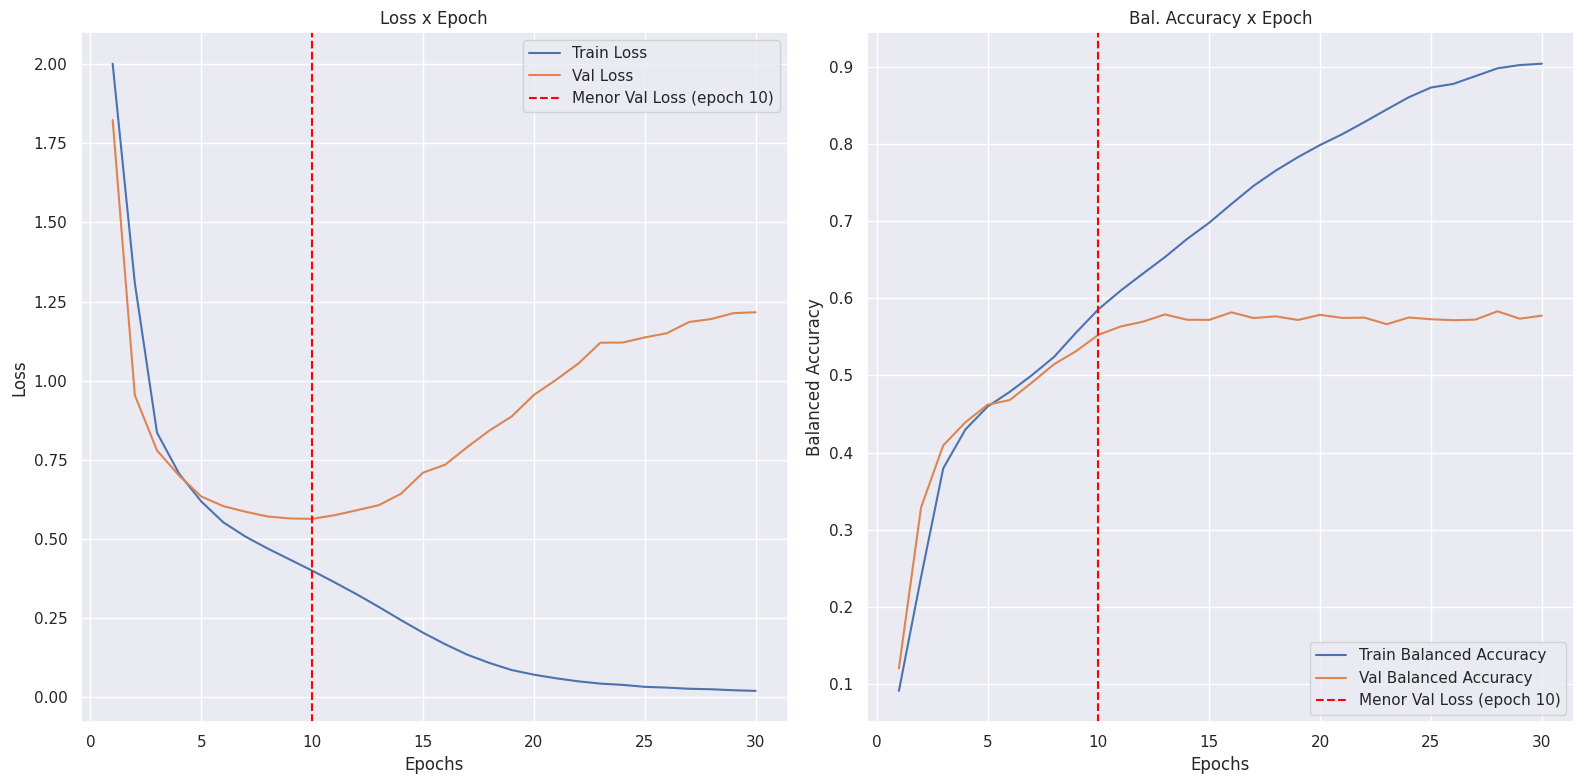

Menor Val Loss: 0.5639 na epoch 10


In [ ]:
epochs = 30

history_deep = train_model(model=deep_model,
                           train_loader=train_loader,
                           val_loader=val_loader,
                           criterion=deep_criterion,
                           optimizer=deep_optimizer,
                           epochs=epochs,
                           device=device,
                           save_path='weights_deep.pth')

plot_history(history=history_deep)

**Atividade (1 pt):** adicione dropout ou regularização L1/L2 e treine o novo modelo. Se for, preciso, faça uma busca pelos hipeparâmetros da regularização/dropout.

In [ ]:
import io
from contextlib import redirect_stdout

class RegularizedProductClassifier(nn.Module):
  def __init__(self, input_dim, n_classes, p_drop=0.3):
    super(RegularizedProductClassifier, self).__init__()
    self.fc1 = nn.Linear(in_features=input_dim, out_features=1024)
    self.fc2 = nn.Linear(in_features=1024, out_features=512)
    self.fc3 = nn.Linear(in_features=512, out_features=256)
    self.fc4 = nn.Linear(in_features=256, out_features=128)
    self.fc5 = nn.Linear(in_features=128, out_features=n_classes)
    self.relu = nn.ReLU()
    self.dropout = nn.Dropout(p=p_drop)

  def forward(self, x):
    x = self.dropout(self.relu(self.fc1(x)))
    x = self.dropout(self.relu(self.fc2(x)))
    x = self.dropout(self.relu(self.fc3(x)))
    x = self.dropout(self.relu(self.fc4(x)))
    # sem dropout antes da saída
    return self.fc5(x)

In [ ]:
#Busca de hiperparâmetros (dropout x weight_decay = L2)
param_grid = [
    {'p_drop': 0.2, 'weight_decay': 0.0},
    {'p_drop': 0.3, 'weight_decay': 1e-4},
    {'p_drop': 0.5, 'weight_decay': 1e-4},
    {'p_drop': 0.3, 'weight_decay': 1e-3},
]

# menos épocas na busca para reduzir custo
search_epochs = 20
results = []
for params in param_grid:
  torch.manual_seed(42)
  m = RegularizedProductClassifier(input_dim=features,
                                   n_classes=n_classes,
                                   p_drop=params['p_drop']).to(device)

  crit = nn.CrossEntropyLoss().to(device)
  opt  = optim.SGD(m.parameters(), lr=1e-2, weight_decay=params['weight_decay'])
  tag = f"drop{params['p_drop']}_wd{params['weight_decay']}"

  with redirect_stdout(io.StringIO()):
    h = train_model(model=m, train_loader=train_loader, val_loader=val_loader,
                    criterion=crit, optimizer=opt, epochs=search_epochs,
                    device=device, save_path=f'search_{tag}.pth')

  results.append({
      'p_drop': params['p_drop'],
      'weight_decay': params['weight_decay'],
      'best_val_bal_acc': max(h['val_bal_acc']),
      'min_val_loss': min(h['val_loss']),
      'best_epoch': int(np.argmin(h['val_loss'])) + 1,
      'gap_train_val': h['train_bal_acc'][-1] - h['val_bal_acc'][-1],
  })

  print(f"{tag} -> val_bal_acc={results[-1]['best_val_bal_acc']:.4f} | "
        f"min_val_loss={results[-1]['min_val_loss']:.4f} | "
        f"gap={results[-1]['gap_train_val']:.4f}")

search_df = pd.DataFrame(results).sort_values('best_val_bal_acc', ascending=False)
display(search_df)

Epoch [1 / 20]:   0%|          | 2/875 [00:00<00:44, 19.51it/s, loss=2.46]

drop0.2_wd0.0 -> val_bal_acc=0.5912 | min_val_loss=0.5358 | gap=0.0480


Epoch [1 / 20]:   0%|          | 3/875 [00:00<00:41, 20.99it/s, loss=2.46]

drop0.3_wd0.0001 -> val_bal_acc=0.5725 | min_val_loss=0.5349 | gap=0.0198


Epoch [1 / 20]:   0%|          | 4/875 [00:00<00:27, 31.68it/s, loss=2.46]

drop0.5_wd0.0001 -> val_bal_acc=0.4782 | min_val_loss=0.5815 | gap=0.0019


drop0.3_wd0.001 -> val_bal_acc=0.5613 | min_val_loss=0.5370 | gap=0.0223


,p_drop,weight_decay,best_val_bal_acc,min_val_loss,best_epoch,gap_train_val
0,0.2,0.0000,0.591208,0.535820,17,0.048041
1,0.3,0.0001,0.572532,0.534938,20,0.019784
3,0.3,0.0010,0.561322,0.537017,20,0.022343
2,0.5,0.0001,0.478159,0.581487,20,0.001852


Melhor config: dropout=0.2, weight_decay=0.0


Epoch [1 / 30] Train Loss: 2.0185, Train Bal. Acc: 0.0880 | Val Loss: 1.8677, Val Bal. Acc: 0.0848
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.0848) salvo em weights_reg.pth
----------------------------------------------------------------------------------------------------


Epoch [2 / 30] Train Loss: 1.5256, Train Bal. Acc: 0.1879 | Val Loss: 1.0604, Val Bal. Acc: 0.3061
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.3061) salvo em weights_reg.pth
----------------------------------------------------------------------------------------------------


Epoch [3 / 30] Train Loss: 0.9818, Train Bal. Acc: 0.3309 | Val Loss: 0.8327, Val Bal. Acc: 0.3804
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.3804) salvo em weights_reg.pth
----------------------------------------------------------------------------------------------------


Epoch [4 / 30] Train Loss: 0.8291, Train Bal. Acc: 0.3916 | Val Loss: 0.7425, Val Bal. Acc: 0.4134
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.4134) salvo em weights_reg.pth
----------------------------------------------------------------------------------------------------


...

Epoch [26 / 30] Train Loss: 0.2476, Train Bal. Acc: 0.6905 | Val Loss: 0.5947, Val Bal. Acc: 0.6011


Epoch [27 / 30] Train Loss: 0.2319, Train Bal. Acc: 0.7010 | Val Loss: 0.6140, Val Bal. Acc: 0.6044
----------------------------------------------------------------------------------------------------
Melhor modelo atualizado (Bal. Acc: 0.6044) salvo em weights_reg.pth
----------------------------------------------------------------------------------------------------


Epoch [28 / 30] Train Loss: 0.2164, Train Bal. Acc: 0.7117 | Val Loss: 0.6170, Val Bal. Acc: 0.6012


Epoch [29 / 30] Train Loss: 0.2032, Train Bal. Acc: 0.7135 | Val Loss: 0.6339, Val Bal. Acc: 0.6011


Epoch [30 / 30] Train Loss: 0.1867, Train Bal. Acc: 0.7264 | Val Loss: 0.6546, Val Bal. Acc: 0.5976


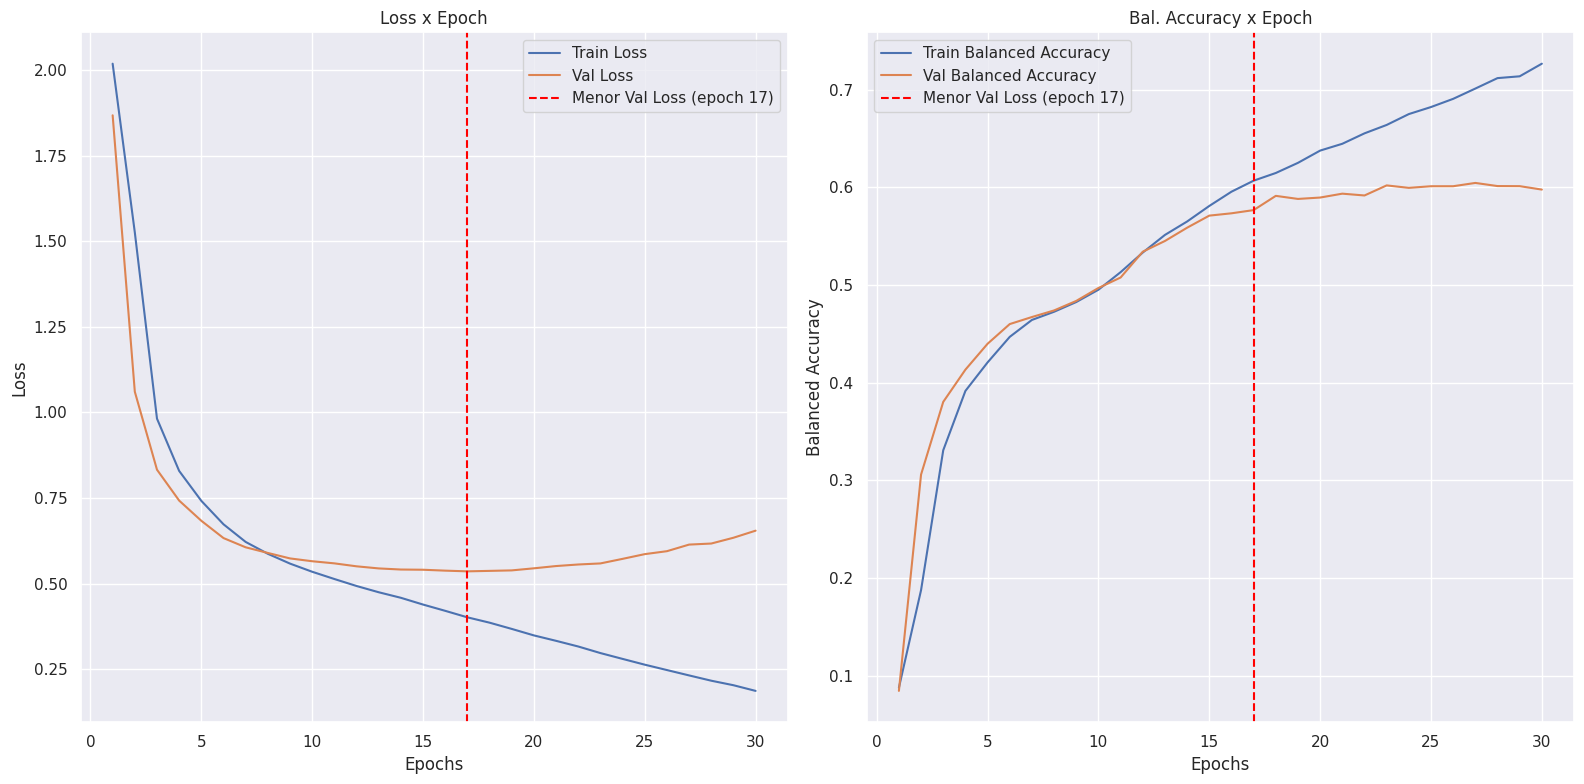

Menor Val Loss: 0.5358 na epoch 17


In [ ]:
# Treino final com a melhor configuração
best_params = search_df.iloc[0]
print(f"Melhor config: dropout={best_params['p_drop']}, weight_decay={best_params['weight_decay']}")

torch.manual_seed(42)
reg_model = RegularizedProductClassifier(input_dim=features,
                                        n_classes=n_classes,
                                        p_drop=float(best_params['p_drop'])).to(device)
reg_criterion = nn.CrossEntropyLoss().to(device)
reg_optimizer = optim.SGD(reg_model.parameters(), lr=1e-2,
                          weight_decay=float(best_params['weight_decay']))

history_reg = train_model(model=reg_model,
                          train_loader=train_loader,
                          val_loader=val_loader,
                          criterion=reg_criterion,
                          optimizer=reg_optimizer,
                          epochs=30,
                          device=device,
                          save_path='weights_reg.pth')

plot_history(history=history_reg)

**Atividade (1 pt):** avalie os modelos treinados e compare com os resultados anteriores.

In [ ]:
def get_metrics(model, loader, device="cpu"):
    y_t, probs = predict_all(model, loader, device=device)
    y_p = probs.argmax(axis=1)
    return (
        {
            "Accuracy": metrics.accuracy_score(y_t, y_p),
            "Balanced Accuracy": metrics.balanced_accuracy_score(y_t, y_p),
            "F1 (macro)": metrics.f1_score(y_t, y_p, average="macro"),
            "F1 (weighted)": metrics.f1_score(y_t, y_p, average="weighted"),
        },
        y_t,
        y_p,
        probs,
    )

In [ ]:
# Recarrega os melhores checkpoints de cada arquitetura
m_simple = ProductClassifier(input_dim=features, n_classes=n_classes)
m_simple.load_state_dict(torch.load("weights.pth"))
m_simple.to(device).eval()

m_deep = DeepProductClassifier(input_dim=features, n_classes=n_classes)
m_deep.load_state_dict(torch.load("weights_deep.pth"))
m_deep.to(device).eval()

m_reg = RegularizedProductClassifier(
    input_dim=features, n_classes=n_classes, p_drop=float(best_params["p_drop"])
)
m_reg.load_state_dict(torch.load("weights_reg.pth"))
m_reg.to(device).eval()

modelos = {
    "Rede simples (3 camadas)": m_simple,
    "Rede profunda (5 camadas)": m_deep,
    "Rede profunda + regularização": m_reg,
}

comparacao, preds = {}, {}
for nome, m in modelos.items():
    res, y_t, y_p, pr = get_metrics(m, test_loader, device=device)
    comparacao[nome] = res
    preds[nome] = (y_t, y_p, pr)

# Baseline da primeira parte do trabalho
y_log = g.predict(x_test)
comparacao["Regressão Logística"] = {
    "Accuracy": metrics.accuracy_score(ye_test, y_log),
    "Balanced Accuracy": metrics.balanced_accuracy_score(ye_test, y_log),
    "F1 (macro)": metrics.f1_score(ye_test, y_log, average="macro"),
    "F1 (weighted)": metrics.f1_score(ye_test, y_log, average="weighted"),
}

display(pd.DataFrame(comparacao).T.round(4))

,Accuracy,Balanced Accuracy,F1 (macro),F1 (weighted)
Rede simples (3 camadas),0.8224,0.5818,0.5679,0.8248
Rede profunda (5 camadas),0.8064,0.5508,0.5355,0.8115
Rede profunda + regularização,0.8374,0.5751,0.5713,0.8385
Regressão Logística,0.8398,0.5886,0.5894,0.8406


,Rede simples (3 camadas),Rede profunda (5 camadas),Rede profunda + regularização,Regressão Logística,suporte
Debt collection,0.812,0.804,0.834,0.845,13309
Mortgage,0.920,0.895,0.928,0.928,7471
Student loan,0.880,0.878,0.896,0.873,5258
Credit reporting,0.805,0.780,0.817,0.822,5063
Credit card,0.768,0.732,0.786,0.798,2462
Bank account or service,0.758,0.758,0.774,0.779,2012
Consumer Loan,0.609,0.589,0.624,0.609,1457
Payday loan,0.433,0.319,0.338,0.390,210
Money transfers,0.473,0.385,0.434,0.495,182
Prepaid card,0.524,0.429,0.469,0.503,147


=== Rede profunda + regularização ===
Accuracy: 0.837
Accuracy (balanced): 0.575
Classes omitidas (< 10 amostras): Virtual currency (n=2)
                         precision    recall  f1-score   support

Bank account or service       0.73      0.77      0.75      2012
          Consumer Loan       0.55      0.62      0.58      1457
            Credit card       0.68      0.79      0.73      2462
       Credit reporting       0.77      0.82      0.79      5063
        Debt collection       0.89      0.83      0.86     13309
        Money transfers       0.49      0.43      0.46       182
               Mortgage       0.92      0.93      0.92      7471
Other financial service       0.00      0.00      0.00        48
            Payday loan       0.37      0.34      0.35       210
           Prepaid card       0.52      0.47      0.49       147
           Student loan       0.92      0.90      0.91      5258
       Virtual currency       0.00      0.00      0.00         2

               

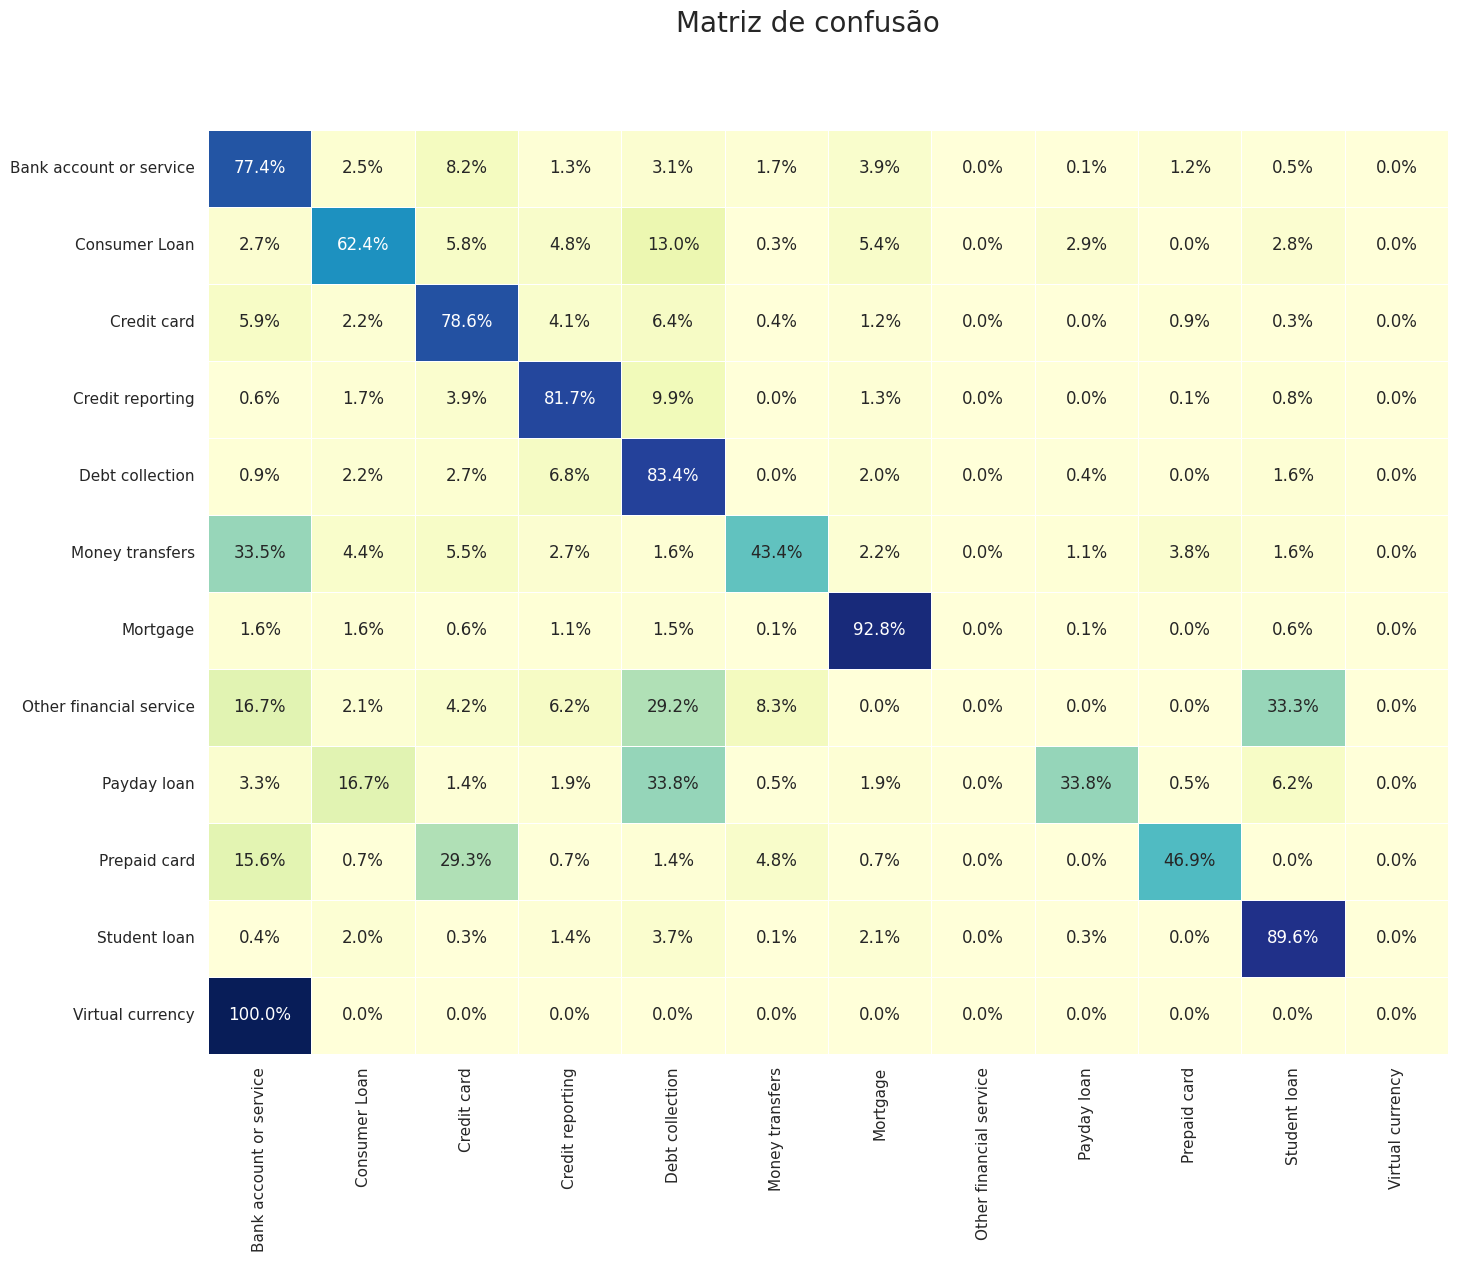

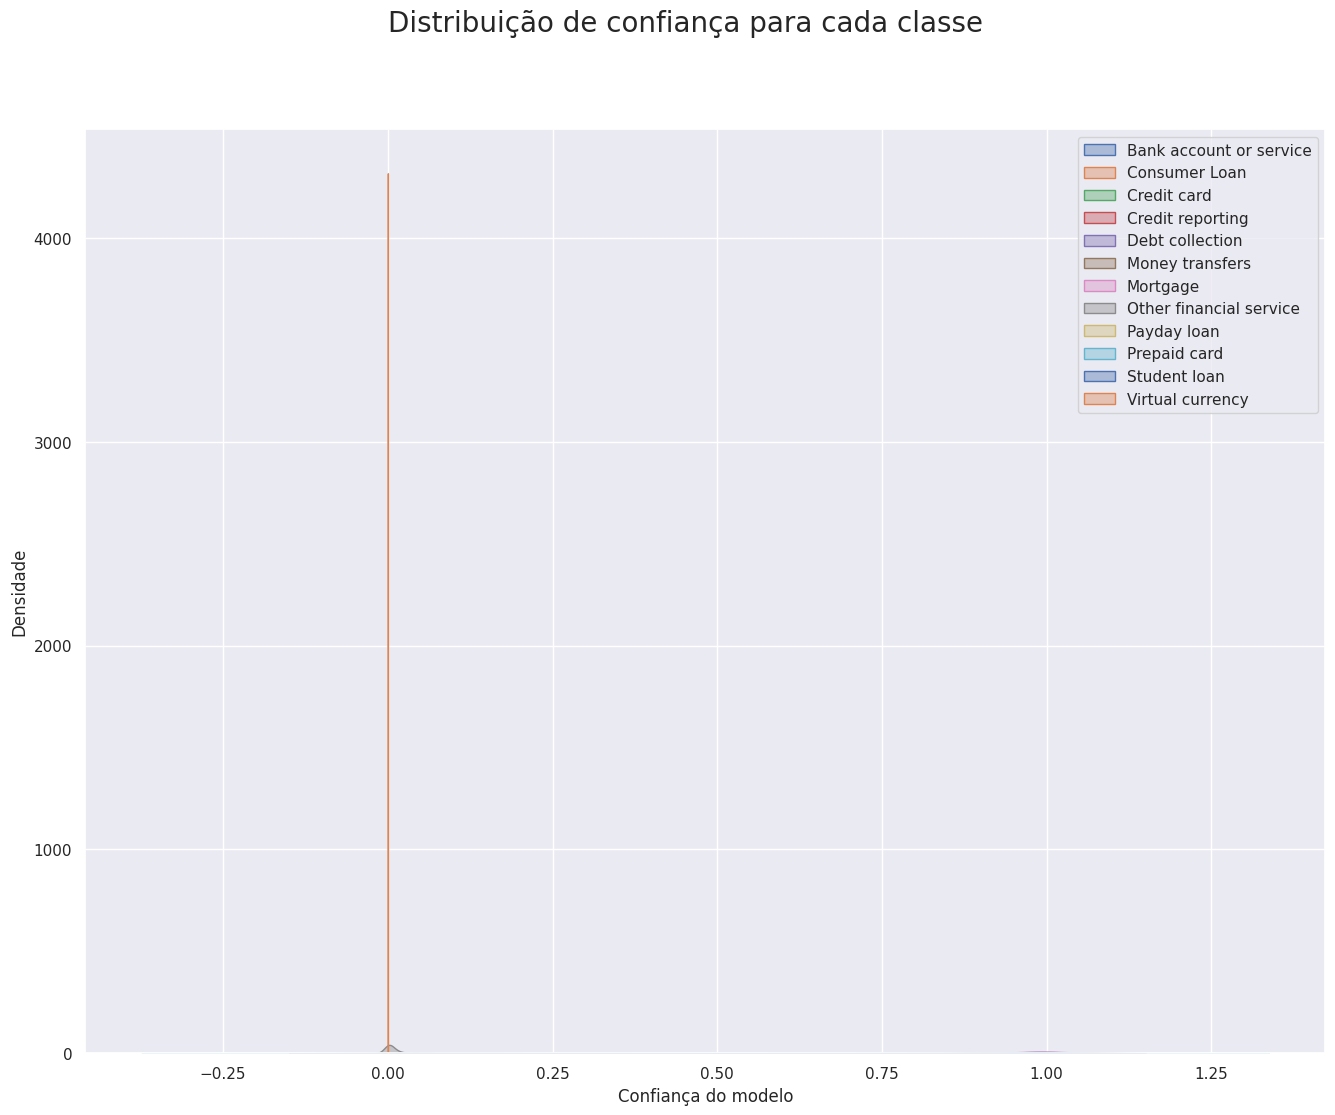

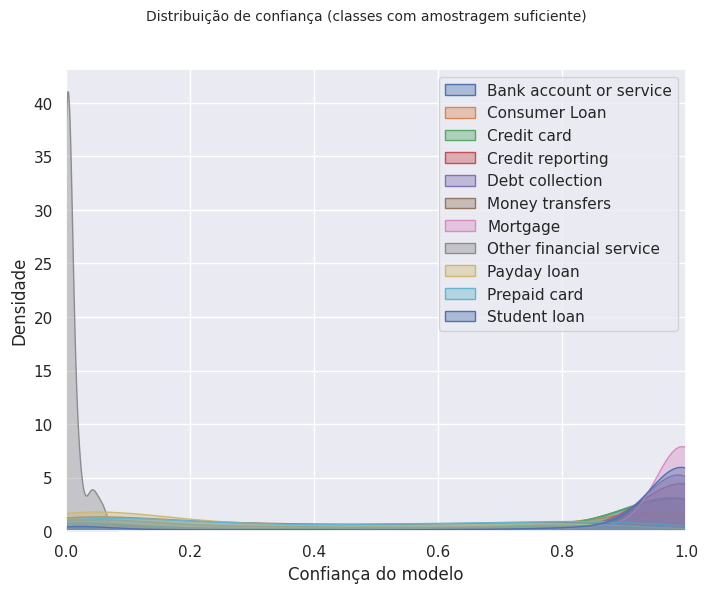

In [ ]:
# Recall (= acurácia) por classe, lado a lado
recalls = {}
for nome, (y_t, y_p, _) in preds.items():
    recalls[nome] = metrics.recall_score(y_t, y_p, average=None, zero_division=0)
recalls['Regressão Logística'] = metrics.recall_score(ye_test, y_log, average=None, zero_division=0)

recall_df = pd.DataFrame(recalls, index=label_enc.classes_).round(3)
recall_df['suporte'] = np.bincount(ye_test, minlength=n_classes)
display(recall_df.sort_values('suporte', ascending=False))

# Detalhamento do melhor modelo
melhor = 'Rede profunda + regularização'
y_t, y_p, pr = preds[melhor]

print(f'=== {melhor} ===')
evaluate(y_t, y_p, pr, labels=label_enc.classes_)
plot_confidence(y_t, pr, labels=label_enc.classes_)
print(classification_report(y_t, y_p, target_names=label_enc.classes_, zero_division=0))

In [ ]:
historicos = {
    "Rede simples (3 camadas)": history,
    "Rede profunda (5 camadas)": history_deep,
    "Rede profunda + regularização": history_reg,
}

n_params = {
    "Rede simples (3 camadas)": sum(p.numel() for p in m_simple.parameters()),
    "Rede profunda (5 camadas)": sum(p.numel() for p in m_deep.parameters()),
    "Rede profunda + regularização": sum(p.numel() for p in m_reg.parameters()),
}

tabela = pd.DataFrame(comparacao).T

for nome, h in historicos.items():
    tabela.loc[nome, "Menor Val Loss"] = min(h["val_loss"])
    tabela.loc[nome, "Epoch (overfit)"] = int(np.argmin(h["val_loss"])) + 1
    tabela.loc[nome, "Gap treino/val"] = h["train_bal_acc"][-1] - h["val_bal_acc"][-1]
    tabela.loc[nome, "Parâmetros"] = n_params[nome]

tabela = tabela.round(4)
tabela["Epoch (overfit)"] = tabela["Epoch (overfit)"].astype("Int64")
tabela["Parâmetros"] = tabela["Parâmetros"].astype("Int64")

display(tabela)


,Accuracy,Balanced Accuracy,F1 (macro),F1 (weighted),Menor Val Loss,Epoch (overfit),Gap treino/val,Parâmetros
Rede simples (3 camadas),0.8224,0.5818,0.5679,0.8248,0.5276,12,0.1956,659212
Rede profunda (5 camadas),0.8064,0.5508,0.5355,0.8115,0.5639,10,0.3266,1740172
Rede profunda + regularização,0.8374,0.5751,0.5713,0.8385,0.5358,17,0.1288,1740172
Regressão Logística,0.8398,0.5886,0.5894,0.8406,NaN,<NA>,NaN,<NA>


É possível observar que o aumento da capacidade da rede piorou o desempenho. A rede neueral profunda caiu em todas as métricas e passou a ter overfitting mais cedo, com o menor val loss ocorrendo na epoch 10 contra 14 da rede simples. Isso reforça o ponto anterior que esse problema é de natureza linear.

A busca de hiperparâmetros testou quatro combinações de dropout e weight decay (L2) por 20 épocas. A melhor configuração foi com dropout de 0,2 sem L2, com 0,5912 de balanced accuracy. As configurações com L2 ativo (1e-4 e 1e-3) ficaram atrás (0,5725 e 0,5613), e dropout 0,5 piorou fortemente o modelo (0,4782), sendo que o gap baixo entre treino e validação indica underfitting. Entre dropout e L1/L2, a busca selecionou apenas o dropout.

Com o método de regularização, o overfitting passou de 10 para 17 epochs, o val loss mínimo melhorou de 0,5639 para 0,5358 e a acurácia subiu para 0,8374, o que é desejado com esse método e foi a melhor entre as três redes. Porém, a balanced accuracy piorou em relação à rede simples (0,5751 contra 0,5812) seguindo o que se pode ver no Recall por classe: Melhorou nas classes majoritárias e piorou nas classes minoritárias, que já eram a causa da acurácia estar baixa nos modelos anteriores. O dropout reduziu a variância empurrando a predição para as classes frequentes, o que piora a acurácia balanceada.

Portanto, conclui-se que no balanço geral a regressão logística permanece o melhor modelo, reforçando que a fronteira desse problema está mais próxima de ser linear e o gargalo está no desbalanceamento do dataset.

----------
----------

## Redes Neurais - Tensorflow
Iremos treinar alguns modelos de redes neurais, variando número de camadas e quantidade de neurônios em cada camada.

In [48]:
epochs = 5
batch_size = 128
input_shape = [features]

Vamos converter os rótulos em vetores *One Hot Encoded*:

In [49]:
from keras.utils import to_categorical

y_ohe_train = to_categorical(ye_train, num_classes=n_classes)
y_ohe_test = to_categorical(ye_test,  num_classes=n_classes)

**Atividade (1 pt):** defina uma arquitetura de uma rede neural capaz de classificar os diferentes produtos a partir da conversa dos clientes. Compile a sua rede com a loss `categorical_crossentropy`, optimizador `SGD` e defina as métricas relevantes para o problema.

In [50]:
import tensorflow as tf
from keras import Sequential, callbacks
from keras.layers import InputLayer, Dense, Dropout
from keras.regularizers import l2
from tensorflow.keras.optimizers import SGD

tf.random.set_seed(42)

x_train_dense = x_train.toarray()
x_test_dense  = x_test.toarray()

input_shape = [features]

model = Sequential([
    InputLayer(input_shape),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(n_classes, activation='softmax'),
])

model.compile(optimizer=SGD(learning_rate=1e-2),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659,212 (2.51 MB)

 Trainable params: 659,212 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

### Treinando a rede neural

**Atividade (1 pt):** treine o modelo definido acima sobre o conjunto, respeitando as seguintes regras:

1. Separe um subconjunto do treino para validação.
2. Utilize alguma técnica para conservar os parâmetros que melhor generalizam o problema, como `ModelCheckpoint` (salve o modelo com nome de `weights.h5`).

In [51]:
epochs = 30
batch_size = 128
validation_split = 0.2

history_keras = model.fit(
    x_train_dense,
    y_ohe_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1,
    callbacks=[
        callbacks.TerminateOnNaN(),
        callbacks.ModelCheckpoint(
            ".weights.h5",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
    ],
)


Epoch 1/30
870/875 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5394 - loss: 1.4237
Epoch 1: val_loss improved from None to 0.77251, saving model to .weights.h5

Epoch 1: finished saving model to .weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.6701 - loss: 1.0676 - val_accuracy: 0.7684 - val_loss: 0.7725
Epoch 2/30
873/875 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7916 - loss: 0.6908
Epoch 2: val_loss improved from 0.77251 to 0.67393, saving model to .weights.h5

Epoch 2: finished saving model to .weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8003 - loss: 0.6598 - val_accuracy: 0.7958 - val_loss: 0.6739
Epoch 3/30
872/875 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8209 - loss: 0.5898
Epoch 3: val_loss improved from 0.67393 to 0.64043, saving model to .weights.h5

Epoch 3: finished saving model to .weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.8245 - loss: 0.5754 - val_accuracy: 0.8045 - val_loss: 0.6404
Epoc

In [52]:
model.load_weights('.weights.h5')

O método `model.fit` retorna `model.history`, e contem algumas informações interessantes a respeito do histórico de treinamento.

**Atividade (1 pt):** plote um gráfico de linhas exibindo a evolução dos valores da função *loss* sobre o conjunto de treino e validação. A partir de qual `epoch` a rede começou a super-especializar?

,accuracy,loss,val_accuracy,val_loss
0,0.670111,1.067626,0.768360,0.772514
1,0.800264,0.659808,0.795792,0.673935
2,0.824536,0.575358,0.804472,0.640430
3,0.837850,0.528338,0.809080,0.624765
4,0.848031,0.494786,0.812330,0.616564


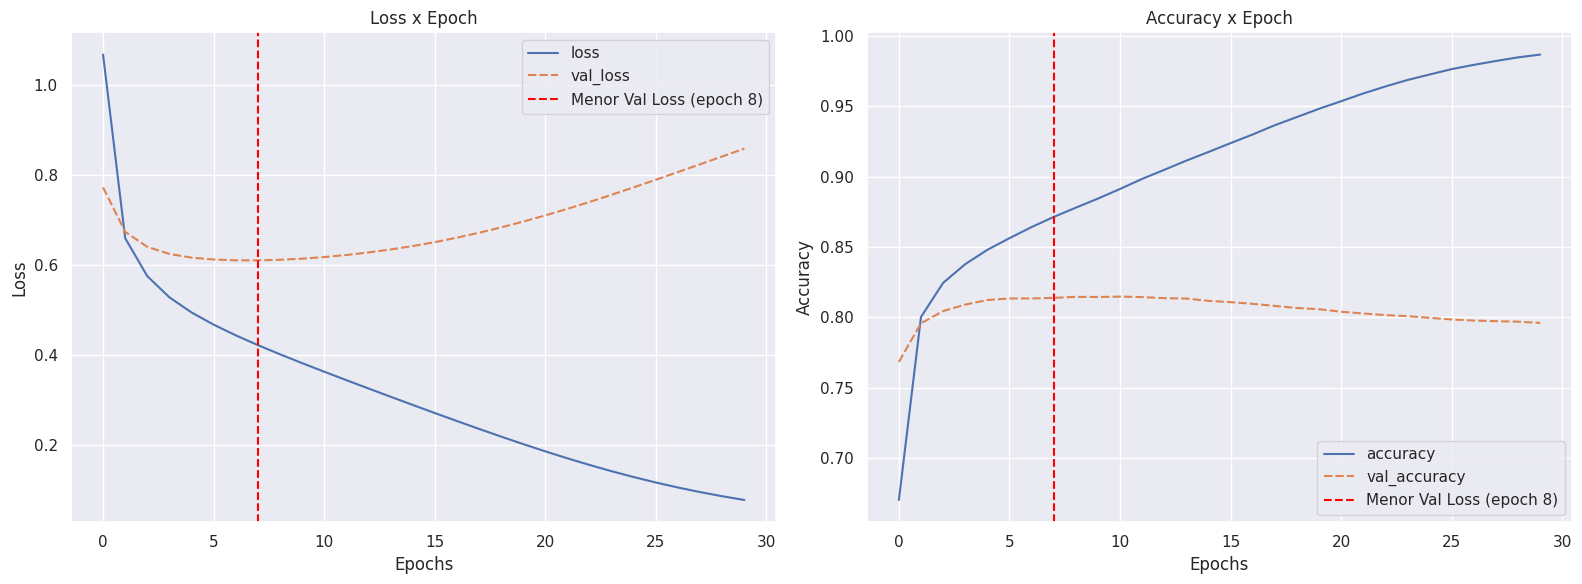

Menor Val Loss: 0.6105 na epoch 8


In [60]:
history_f = pd.DataFrame(model.history.history)
display(history_f.head())

best_epoch = int(history_f["val_loss"].idxmin()) + 1

plt.figure(figsize=(16, 6))

plt.subplot(121)
sns.lineplot(data=history_f[["loss", "val_loss"]])
plt.axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Menor Val Loss (epoch {best_epoch})",
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss x Epoch")
plt.legend()

plt.subplot(122)
sns.lineplot(data=history_f[["accuracy", "val_accuracy"]])
plt.axvline(
    best_epoch - 1,
    color="red",
    linestyle="--",
    label=f"Menor Val Loss (epoch {best_epoch})",
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy x Epoch")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Menor Val Loss: {history_f['val_loss'].min():.4f} na epoch {best_epoch}")


A rede começou a apresentar overfitting a partir da epoch 8, ponto em que a loss de validação atingiu seu mínimo (0,6091). A partir daí as curvas divergem: a loss de treino continua caindo de 0,4244 até 0,0769 na epoch 30, enquanto a curva de validação sobe até 0,8562, mais de 40% acima do mínimo. A acurácia confirma isso, pois o o treino chega a 98,7% enquanto a validação para em torno de 81% e depois cai para 79,6%, abrindo uma diferença de quase 19 pontos.

Vale notar que o overfitting aqui aparece mais cedo do que na implementação equivalente em PyTorch (epoch 14), apesar de as duas redes terem a mesma arquitetura e o mesmo número de parâmetros (659.212). A diferença está na forma de separar a validação: o  validation_split  do Keras reserva os últimos 20% das amostras sem embaralhar, e como o dataset foi ordenado por data e dividido cronologicamente, a validação corresponde ao período mais recente do treino. Esse deslocamento temporal torna a validação mais exigente do que a partição aleatória estratificada usada no PyTorch, antecipando o ponto em que a rede deixa de generalizar.

### Avaliando o modelo treinado

**Atividade (1 pt):** teste o modelo treinado utilizando o subconjunto de teste. Reporte a acurácia para cada classe e a matriz de confusão percentual (usando a função `evaluate` definida anteriormente).

Test loss: 0.5800
Test accuracy (NOT BALANCED): 0.8229

Accuracy: 0.823
Accuracy (balanced): 0.560
Classes omitidas (< 10 amostras): Virtual currency (n=2)
                         precision    recall  f1-score   support

Bank account or service       0.76      0.73      0.74      2012
          Consumer Loan       0.56      0.56      0.56      1457
            Credit card       0.65      0.79      0.71      2462
       Credit reporting       0.72      0.81      0.77      5063
        Debt collection       0.87      0.83      0.85     13309
        Money transfers       0.54      0.48      0.51       182
               Mortgage       0.90      0.92      0.91      7471
Other financial service       0.00      0.00      0.00        48
            Payday loan       0.41      0.36      0.38       210
           Prepaid card       0.52      0.39      0.45       147
           Student loan       0.93      0.84      0.89      5258
       Virtual currency       0.00      0.00      0.00         

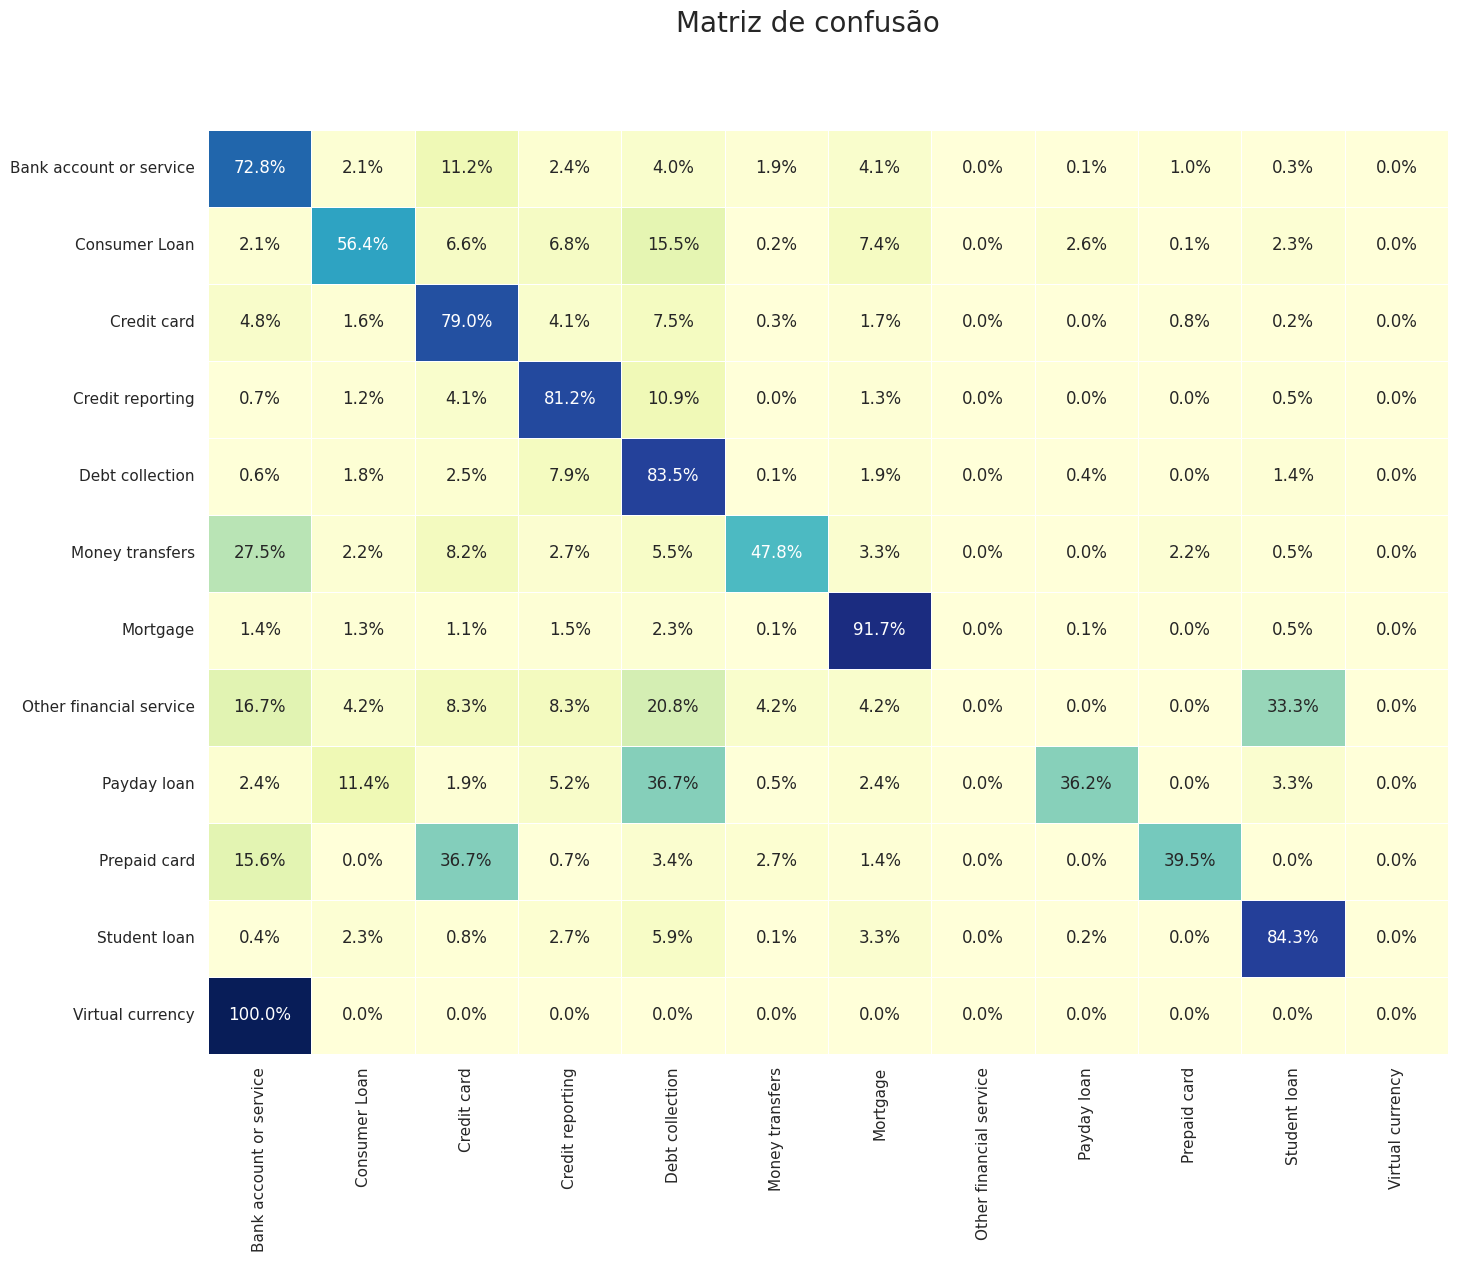

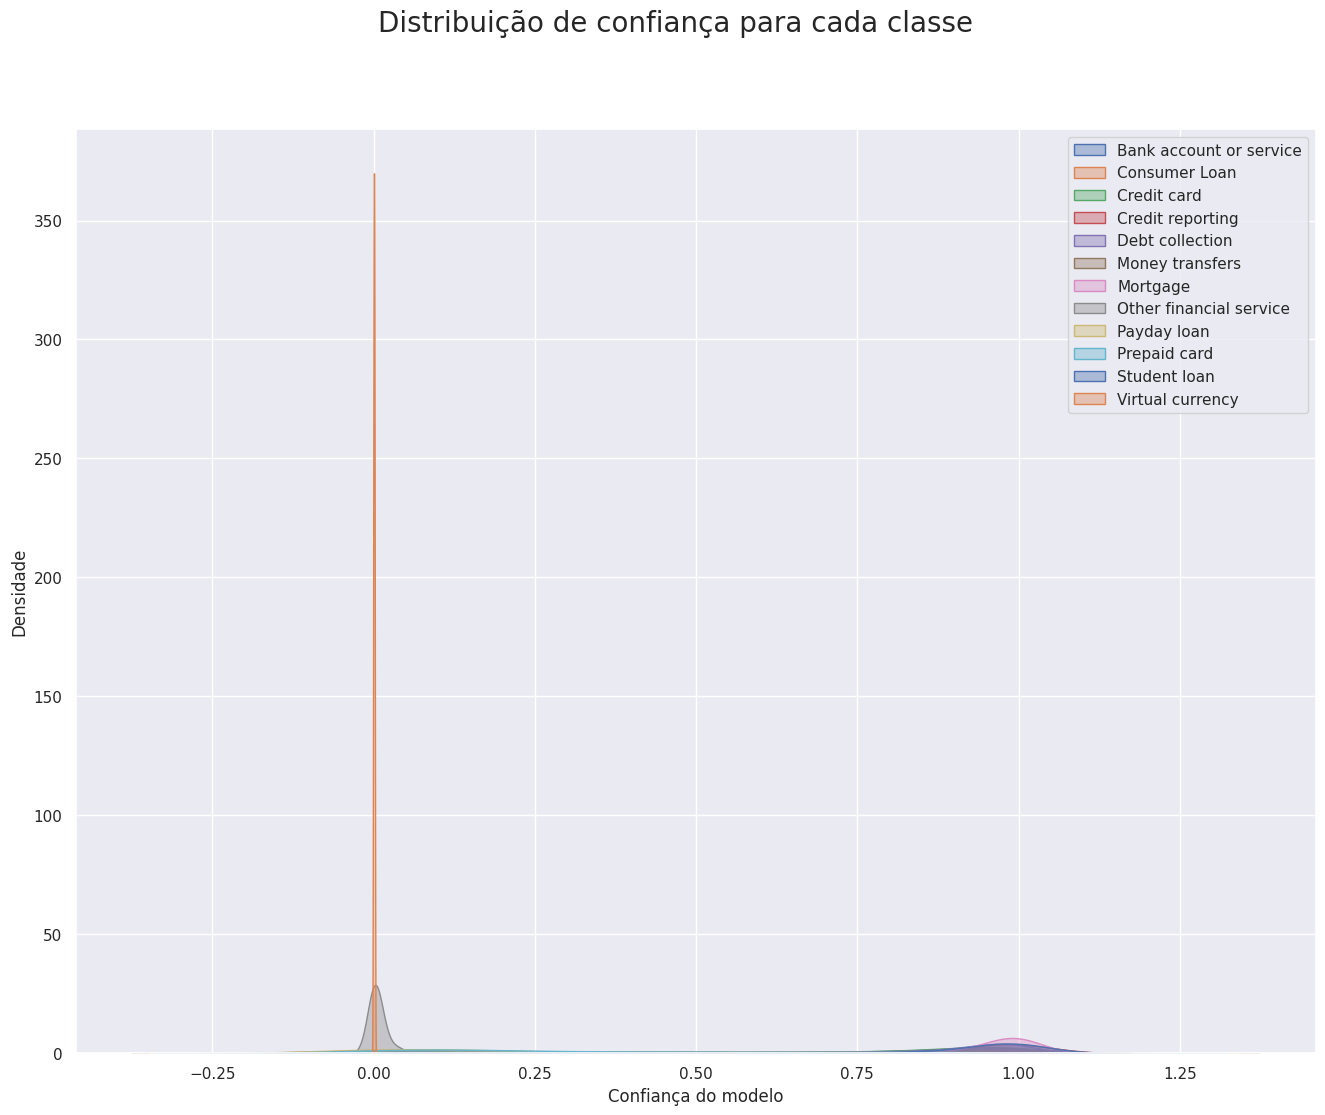

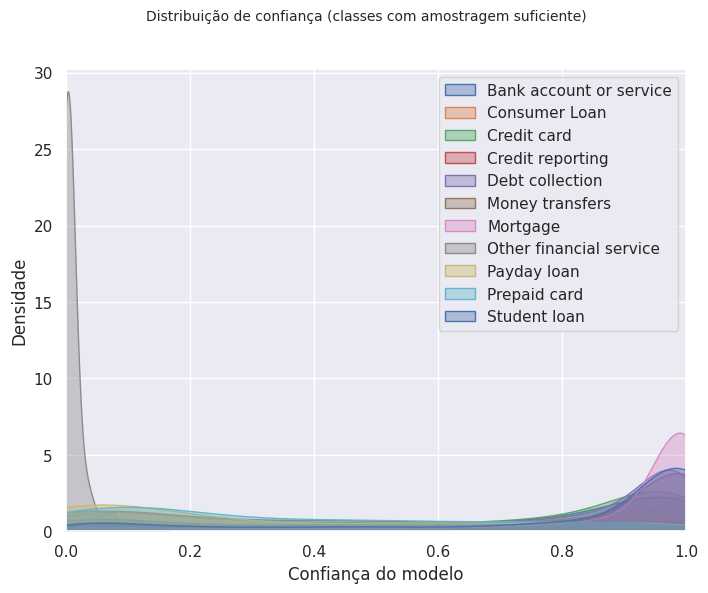

In [61]:
score = model.evaluate(x_test_dense, y_ohe_test, verbose=0)
print(f"Test loss: {score[0]:.4f}")
print(f"Test accuracy (NOT BALANCED): {score[1]:.4f}\n")

probs_keras = model.predict(x_test_dense, verbose=0)
pred_keras = probs_keras.argmax(axis=1)

evaluate(ye_test, pred_keras, probs_keras, labels=label_enc.classes_)
plot_confidence(ye_test, probs_keras, labels=label_enc.classes_)

print(
    classification_report(
        ye_test, pred_keras, target_names=label_enc.classes_, zero_division=0
    )
)

--------

Repita agora a definição, treinamento e avaliação de uma rede neural mais complexa, aumentando o número de camadas ou a quantidade de neurônios nas camadas da rede anterior:

**Atividade (1 pt):** defina uma rede neural mais complexa e a compile com as mesmas configurações da rede anterior.

Resultados obtidos: Test loss: 0,5822, Accuracy: 0,8232, Balanced accuracy: 0,5580.

A distância entre acurácia (82,3%) e acurácia balanceada (55,8%) repete o padrão já observado nos modelos anteriores e tem a mesma causa: quatro classes concentram 82,7% do conjunto de teste, então acertar as majoritárias infla a métrica global. A balanced accuracy, equivalente à média dos recalls (macro avg = 0,56 no relatório), mostra o desempenho real.

A acurácia por classe segue novamente o volume de amostras: Mortgage (0,92), Debt collection (0,83), Student loan (0,83), Credit reporting (0,81) e Credit card (0,79) vão bem, enquanto Money transfers (0,47), Prepaid card (0,37) e Payday loan (0,35) ficam bem abaixo. Other financial service (48 amostras) e Virtual currency (2 amostras) mantêm recall zero. A matriz de confusão percentual mostra os mesmos erros já discutidos, confusões entre produtos de crédito e entre transferências e contas bancárias.

Comparando com a rede equivalente em PyTorch, que tem arquitetura e número de parâmetros idênticos (659.212), o modelo Keras praticamente igual, apenas um pouco pior: 0,8232 contra 0,8319 de acurácia e 0,558 contra 0,5812 de balanced accuracy. A queda se concentra nas classes minoritárias e intermediárias, como esperado: Prepaid card caiu de 0,483 para 0,37, Consumer Loan de 0,617 para 0,57 e Student loan de 0,892 para 0,83. A explicação está no critério de checkpoint: o Keras não oferece acurácia balanceada como métrica nativa, então o ModelCheckpoint monitorou val_loss e conservou os pesos da epoch 8, enquanto no PyTorch o critério foi a própria val_bal_acc, que continuou melhorando até a epoch 21. O modelo Keras é, portanto, mais conservador: privilegia as classes frequentes e arrisca menos nas raras.

In [53]:
tf.random.set_seed(42)

model_deep = Sequential([
    InputLayer(input_shape),
    Dense(1024, activation='relu'),
    Dense(512,  activation='relu'),
    Dense(256,  activation='relu'),
    Dense(128,  activation='relu'),
    Dense(n_classes, activation='softmax'),
])

model_deep.compile(optimizer=SGD(learning_rate=1e-2),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

model_deep.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,740,172 (6.64 MB)

 Trainable params: 1,740,172 (6.64 MB)

 Non-trainable params: 0 (0.00 B)

**Atividade (1 pt):** treine a nova rede.

In [54]:
history_deep_keras = model_deep.fit(
    x_train_dense,
    y_ohe_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1,
    callbacks=[
        callbacks.TerminateOnNaN(),
        callbacks.ModelCheckpoint(
            "deep.weights.h5",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=0,
        ),
    ],
)

model_deep.load_weights("deep.weights.h5")

Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.6611 - loss: 1.0867 - val_accuracy: 0.7732 - val_loss: 0.7500
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.8041 - loss: 0.6361 - val_accuracy: 0.8003 - val_loss: 0.6534
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.8306 - loss: 0.5452 - val_accuracy: 0.8065 - val_loss: 0.6252
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.8464 - loss: 0.4914 - val_accuracy: 0.8105 - val_loss: 0.6150
Epoch 5/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.8601 - loss: 0.4495 - val_accuracy: 0.8120 - val_loss: 0.6123
Epoch 6/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.8722 - loss: 0.4125 - val_accuracy: 0.8117 - val_loss: 0.6148
Epoch 7/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.8838 - loss: 0.3776 - val_accuracy: 0.8107 - val_loss: 0.6224
Epoch 8/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.8961 - loss: 0.3434 - 

**Atividade (1 pt):** adicione dropout ou regularização L1/L2 e treine o novo modelo. Se for, preciso, faça uma busca pelos hipeparâmetros da regularização/dropout.

In [55]:
def build_model(p_drop=0.3, l2_reg=0.0, lr=1e-2):
    tf.random.set_seed(42)
    m = Sequential(
        [
            InputLayer(input_shape),
            Dense(1024, activation="relu", kernel_regularizer=l2(l2_reg)),
            Dropout(p_drop),
            Dense(512, activation="relu", kernel_regularizer=l2(l2_reg)),
            Dropout(p_drop),
            Dense(256, activation="relu", kernel_regularizer=l2(l2_reg)),
            Dropout(p_drop),
            Dense(128, activation="relu", kernel_regularizer=l2(l2_reg)),
            Dropout(p_drop),
            Dense(n_classes, activation="softmax"),
        ]
    )
    m.compile(
        optimizer=SGD(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m


param_grid = [
    {"p_drop": 0.2, "l2_reg": 0.0},
    {"p_drop": 0.3, "l2_reg": 1e-4},
    {"p_drop": 0.5, "l2_reg": 1e-4},
    {"p_drop": 0.3, "l2_reg": 1e-3},
]

search_epochs = 20
results_keras = []

for params in param_grid:
    m = build_model(**params)
    h = m.fit(
        x_train_dense,
        y_ohe_train,
        epochs=search_epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=1,
        callbacks=[callbacks.TerminateOnNaN()],
    )

    hf = pd.DataFrame(h.history)
    results_keras.append(
        {
            "p_drop": params["p_drop"],
            "l2_reg": params["l2_reg"],
            "best_val_acc": hf["val_accuracy"].max(),
            "min_val_loss": hf["val_loss"].min(),
            "best_epoch": int(hf["val_loss"].idxmin()) + 1,
            "gap_train_val": hf["accuracy"].iloc[-1] - hf["val_accuracy"].iloc[-1],
        }
    )
    print(
        f"drop{params['p_drop']}_l2{params['l2_reg']} -> "
        f"val_acc={results_keras[-1]['best_val_acc']:.4f} | "
        f"min_val_loss={results_keras[-1]['min_val_loss']:.4f} | "
        f"gap={results_keras[-1]['gap_train_val']:.4f}"
    )

search_keras_df = pd.DataFrame(results_keras).sort_values("min_val_loss")
display(search_keras_df)

# Treino final com a melhor configuração
best_keras = search_keras_df.iloc[0]
print(f"Melhor config: dropout={best_keras['p_drop']}, l2={best_keras['l2_reg']}")

model_reg = build_model(
    p_drop=float(best_keras["p_drop"]), l2_reg=float(best_keras["l2_reg"])
)

history_reg_keras = model_reg.fit(
    x_train_dense,
    y_ohe_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1,
    callbacks=[
        callbacks.TerminateOnNaN(),
        callbacks.ModelCheckpoint(
            "reg.weights.h5",
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=0,
        ),
    ],
)

model_reg.load_weights("reg.weights.h5")

Epoch 1/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.5062 - loss: 1.4715 - val_accuracy: 0.7268 - val_loss: 0.9193
Epoch 2/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.7245 - loss: 0.9077 - val_accuracy: 0.7851 - val_loss: 0.7225
Epoch 3/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.7687 - loss: 0.7701 - val_accuracy: 0.8029 - val_loss: 0.6608
Epoch 4/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.7875 - loss: 0.7022 - val_accuracy: 0.8108 - val_loss: 0.6301
Epoch 5/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.7996 - loss: 0.6593 - val_accuracy: 0.8150 - val_loss: 0.6083
Epoch 6/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.8095 - loss: 0.6240 - val_accuracy: 0.8186 - val_loss: 0.5956
Epoch 7/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.8163 - loss: 0.5968 - val_accuracy: 0.8197 - val_loss: 0.5858
Epoch 8/20
875/875 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.8233 - loss: 0.5734 - 

,p_drop,l2_reg,best_val_acc,min_val_loss,best_epoch,gap_train_val
0,0.2,0.0000,0.829333,0.556247,17,0.039183
1,0.3,0.0001,0.829869,0.760035,20,0.016492
2,0.5,0.0001,0.820510,0.834641,20,-0.019362
3,0.3,0.0010,0.832190,1.663045,20,0.024734


Melhor config: dropout=0.2, l2=0.0
Epoch 1/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.5222 - loss: 1.4496 - val_accuracy: 0.7246 - val_loss: 0.9223
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.7322 - loss: 0.8949 - val_accuracy: 0.7873 - val_loss: 0.7209
Epoch 3/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.7699 - loss: 0.7668 - val_accuracy: 0.8024 - val_loss: 0.6616
Epoch 4/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.7895 - loss: 0.6969 - val_accuracy: 0.8104 - val_loss: 0.6319
Epoch 5/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.8019 - loss: 0.6524 - val_accuracy: 0.8162 - val_loss: 0.6108
Epoch 6/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.8095 - loss: 0.6211 - val_accuracy: 0.8194 - val_loss: 0.5967
Epoch 7/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.8187 - loss: 0.5953 - val_accuracy: 0.8210 - val_loss: 0.5884
Epoch 8/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step -

**Atividade (1 pt):** avalie os modelos treinados e compare com os resultados anteriores.

,Accuracy,Balanced Accuracy,F1 (macro),F1 (weighted),Menor Val Loss,Epoch (overfit),Parâmetros
Keras simples (3 camadas),0.8229,0.5603,0.5641,0.8237,0.6105,8.0,659212.0
Keras profunda (5 camadas),0.8266,0.5549,0.5603,0.8268,0.6123,5.0,1740172.0
Keras profunda + regularização,0.8346,0.5785,0.5754,0.8355,0.5596,17.0,1740172.0


,Keras simples (3 camadas),Keras profunda (5 camadas),Keras profunda + regularização,suporte
Debt collection,0.835,0.846,0.833,13309
Mortgage,0.917,0.928,0.932,7471
Student loan,0.843,0.845,0.872,5258
Credit reporting,0.812,0.795,0.823,5063
Credit card,0.790,0.785,0.804,2462
Bank account or service,0.728,0.711,0.747,2012
Consumer Loan,0.564,0.590,0.605,1457
Payday loan,0.362,0.329,0.371,210
Money transfers,0.478,0.511,0.500,182
Prepaid card,0.395,0.320,0.456,147


=== Keras profunda + regularização ===
Accuracy: 0.835
Accuracy (balanced): 0.578
Classes omitidas (< 10 amostras): Virtual currency (n=2)
                         precision    recall  f1-score   support

Bank account or service       0.77      0.75      0.76      2012
          Consumer Loan       0.59      0.60      0.60      1457
            Credit card       0.65      0.80      0.72      2462
       Credit reporting       0.74      0.82      0.78      5063
        Debt collection       0.89      0.83      0.86     13309
        Money transfers       0.48      0.50      0.49       182
               Mortgage       0.91      0.93      0.92      7471
Other financial service       0.00      0.00      0.00        48
            Payday loan       0.42      0.37      0.40       210
           Prepaid card       0.51      0.46      0.48       147
           Student loan       0.93      0.87      0.90      5258
       Virtual currency       0.00      0.00      0.00         2

              

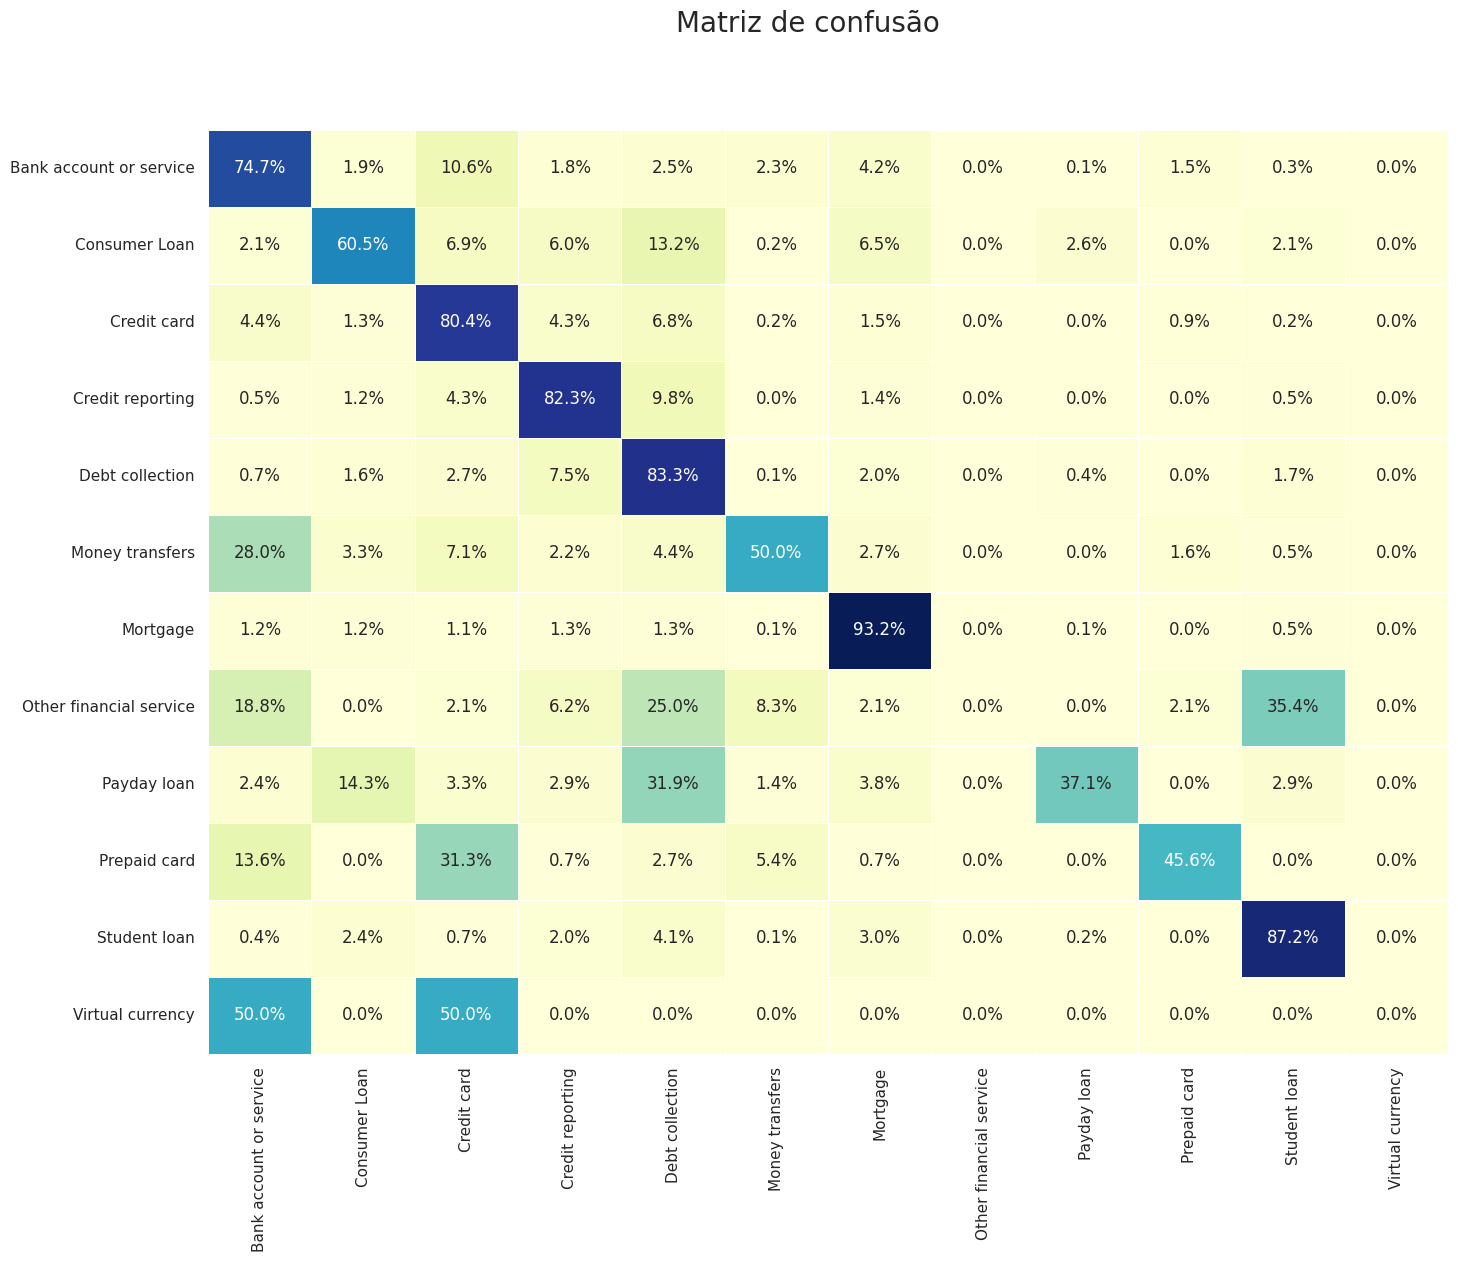

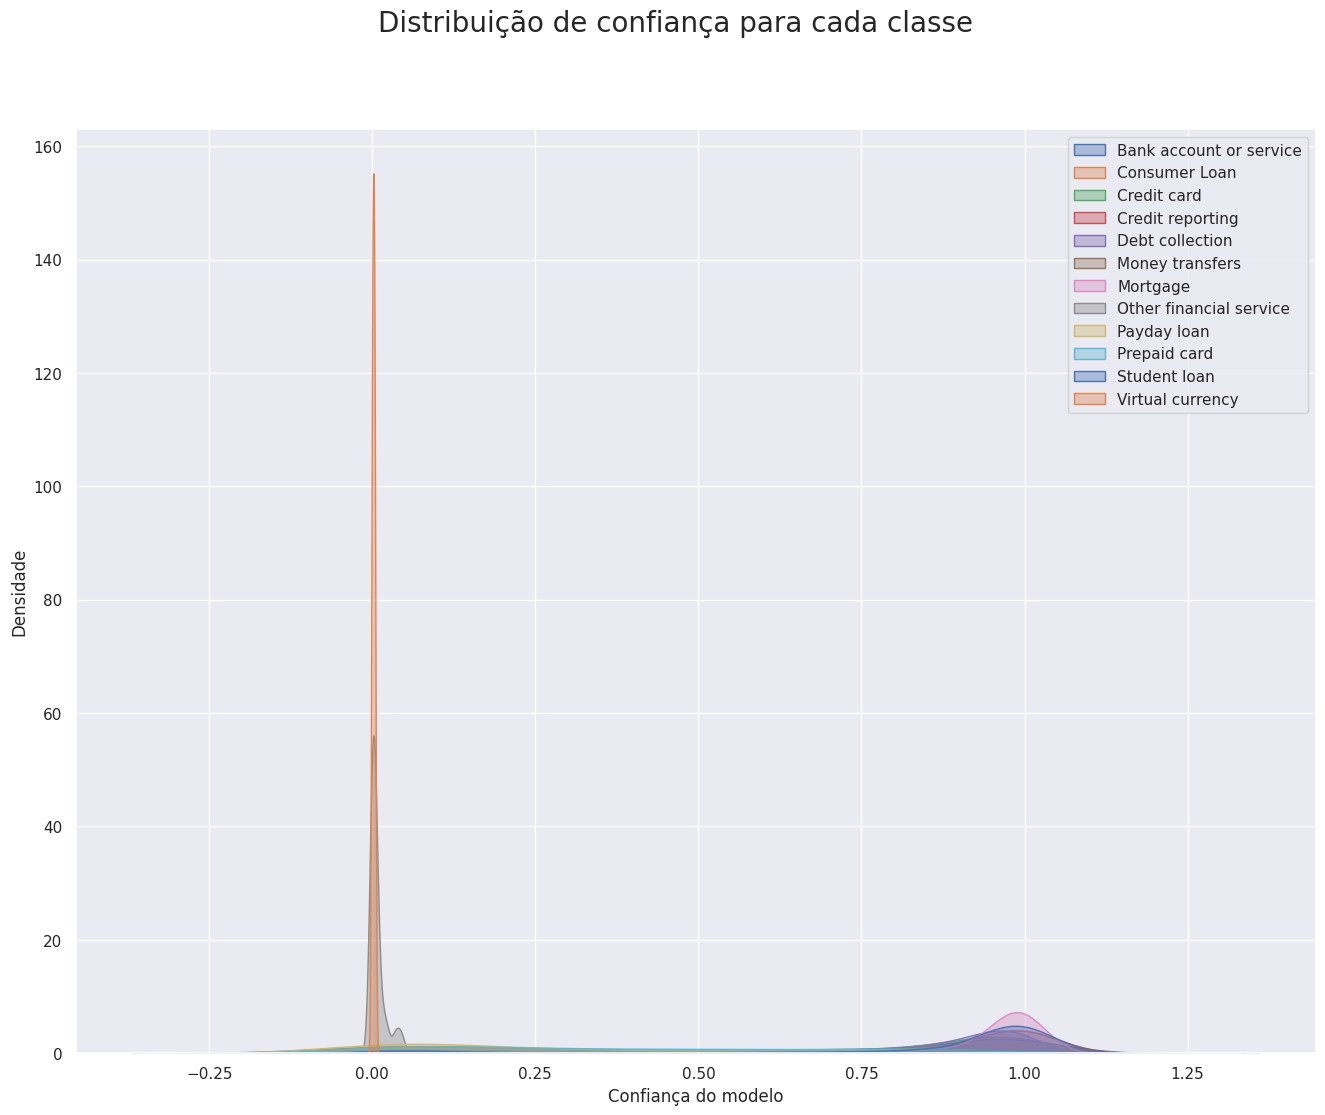

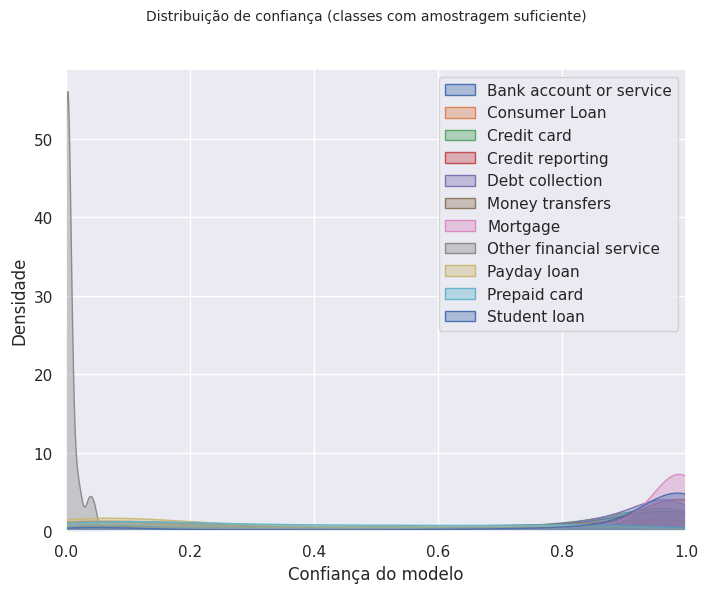

In [59]:
modelos_keras = {
    "Keras simples (3 camadas)": (model, history_keras),
    "Keras profunda (5 camadas)": (model_deep, history_deep_keras),
    "Keras profunda + regularização": (model_reg, history_reg_keras),
}

comparacao_keras, preds_keras = {}, {}

for nome, (m, h) in modelos_keras.items():
    pr = m.predict(x_test_dense, verbose=0)
    yp = pr.argmax(axis=1)
    hf = pd.DataFrame(h.history)

    comparacao_keras[nome] = {
        "Accuracy": metrics.accuracy_score(ye_test, yp),
        "Balanced Accuracy": metrics.balanced_accuracy_score(ye_test, yp),
        "F1 (macro)": metrics.f1_score(ye_test, yp, average="macro"),
        "F1 (weighted)": metrics.f1_score(ye_test, yp, average="weighted"),
        "Menor Val Loss": hf["val_loss"].min(),
        "Epoch (overfit)": int(hf["val_loss"].idxmin()) + 1,
        "Parâmetros": m.count_params(),
    }
    preds_keras[nome] = (yp, pr)

tabela_final = tabela_final = pd.DataFrame(comparacao_keras).T

if "comparacao" in globals():
    tabela_final = pd.concat([pd.DataFrame(comparacao).T, tabela_final])

display(tabela_final.round(4))

# Recall por classe: PyTorch vs Keras vs baseline
recalls_all = dict(recalls) if "recalls" in globals() else {}
for nome, (yp, _) in preds_keras.items():
    recalls_all[nome] = metrics.recall_score(ye_test, yp, average=None, zero_division=0)

recall_all_df = pd.DataFrame(recalls_all, index=label_enc.classes_).round(3)
recall_all_df["suporte"] = np.bincount(ye_test, minlength=n_classes)
display(recall_all_df.sort_values("suporte", ascending=False))

# Detalhamento do melhor modelo Keras
melhor_keras = "Keras profunda + regularização"
yp, pr = preds_keras[melhor_keras]

print(f"=== {melhor_keras} ===")
evaluate(ye_test, yp, pr, labels=label_enc.classes_)
plot_confidence(ye_test, pr, labels=label_enc.classes_)
print(
    classification_report(ye_test, yp, target_names=label_enc.classes_, zero_division=0)
)

Aumentar a capacidade da rede isoladamente não trouxe ganho consistente. A rede profunda (1.740.172 parâmetros, contra 659.212 da simples) melhorou um pouco a acurácia (0,8266 vs 0,8229) mas piorou a acurácia balanceada (0,5549 vs 0,5603), e passou a ter overfitting muito mais cedo: seu menor val loss ocorreu na epoch 5, contra a epoch 8 da rede simples. Ao final das 30 épocas ela chegou a 99,7% de acurácia no treino contra 78,2% na validação, com o val loss aumentando de 0,6123 para 1,420. A capacidade extra se transformou apenas em memorização e overfitting.

A busca de hiperparâmetros testou quatro combinações de dropout e L2 por 20 épocas, selecionando dropout 0,2 sem L2 pelo menor val loss (0,5562). Porém, o Keras inclui a penalidade de regularização no valor de loss reportado, de modo que as configurações com L2 ativo apresentam val loss inflado (1,6630 para L2=1e-3) e não são diretamente comparáveis à configuração sem L2. Usando val_accuracy, que não sofre esse efeito, o ranking mudaria e a configuração dropout 0,3 + L2 1e-3 seria a vencedora (0,8322). A configuração dropout 0,5 confirmou o padrão já observado no PyTorch, ocorrência de underfitting por regularização excessiva.

A regularização foi o único fator que levou a uma melhoria efetiva. O modelo com dropout 0,2 obteve a melhor marca em todas as métricas de teste, adiou o overfitting da epoch 5 para a 17 e reduziu o val loss mínimo de 0,6123 para 0,5596. Além disso, o ganho foi nas categorias onde os valores de acurácia eram menores e menos presentes do dataset, com Prepaid card subindo de 0,320 para 0,456, Consumer Loan de 0,590 para 0,605, Payday loan de 0,329 para 0,371 e Student loan de 0,845 para 0,872, sem perda relevante nas classes majoritárias. Esse comportamento contrasta com o observado no PyTorch, onde o dropout melhorou a acurácia geral mas reduziu a balanceada por empurrar as predições para as classes frequentes. Ainda assim, Other financial service (48 amostras) e Virtual currency (2 amostras) permanecem com recall zero em todas as variantes.

Considerando todos os modelos treinados, a regressão logística permanece o melhor resultado em acurácia balanceada (0,5886) e F1 macro (0,5894), seguida de perto pela rede simples em PyTorch e pela rede regularizada em Keras. Nenhuma das seis redes neurais superou o baseline linear. A conclusão geral, portanto, é de que sobre uma representação TF-IDF de 1.024 dimensões, a fronteira de decisão do problema é essencialmente linear, e nem profundidade, nem largura, nem regularização produziram ganho sobre a regressão logística. O gargalo não é a capacidade do modelo, e sim o desbalanceamento do dataset.